<a href="https://colab.research.google.com/github/amujinho/Machine_Learning/blob/main/Kenya_Digital_Economy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import random

class EconomyAgent:
    def __init__(self, agent_id, initial_wealth=1000, health_status="healthy", employment_status="employed"):
        self.agent_id = agent_id
        self.initial_wealth = initial_wealth # Store initial wealth
        self.wealth = initial_wealth
        self.market_sentiment = 0.5 # A placeholder for market factor
        self.health_status = health_status
        self.employment_status = employment_status
        self.income = 0 # Initialize income
        self._set_initial_income() # Set income based on initial employment status

    def _set_initial_income(self):
        # For simplicity, let's assume a fixed salary for employed and no income for unemployed
        if self.employment_status == "employed":
            self.income = 300 # Example monthly salary
        else:
            self.income = 0 # No income if unemployed

    def update_market_sentiment(self, new_sentiment):
        self.market_sentiment = new_sentiment
        # print(f"Agent {self.agent_id}: Market sentiment updated to {self.market_sentiment}")

    def gain_income(self):
        self.wealth += self.income
        # print(f"Agent {self.agent_id} gained {self.income} KES income. New wealth: {self.wealth:.2f}")

    def update_employment_status(self, new_status):
        if new_status in ["employed", "unemployed"]:
            self.employment_status = new_status
            if new_status == "employed":
                self.income = 300 # Example salary for employed
                print(f"Agent {self.agent_id} is now EMPLOYED. Income: {self.income} KES.")
            else:
                self.income = 0 # No income for unemployed
                print(f"Agent {self.agent_id} is now UNEMPLOYED. Income: {self.income} KES.")
        else:
            print(f"Invalid employment status: {new_status}")

    def display_status(self):
        print(f"Agent {self.agent_id} | Wealth: KES {self.wealth:.2f} | Income: KES {self.income:.2f} | Market Sentiment: {self.market_sentiment:.2f} | Health: {self.health_status} | Employment: {self.employment_status}")


### Implementing Q-Learning for Agent Decision-Making
To enable agents to make autonomous decisions (e.g., choosing between Bank, Company, or NGO), we will integrate a simple Q-learning algorithm into the `EconomyAgent` class. This involves:

1.  **Defining States:** The current state of the agent and the global economy.
2.  **Defining Actions:** The choices an agent can make (e.g., 'interact_bank', 'interact_company', 'interact_ngo').
3.  **Defining Rewards:** How an agent's wealth changes based on an action and the environment.
4.  **Q-Table:** A table where the agent stores learned action-value pairs.
5.  **Learning Rule:** How the Q-table is updated over time.



In [2]:
import numpy as np


class QLearningAgent(EconomyAgent):
    def __init__(self, agent_id, initial_wealth=1000, health_status="healthy", employment_status="employed", learning_rate=0.1, discount_factor=0.9, exploration_rate=0.2):
        super().__init__(agent_id, initial_wealth, health_status, employment_status)
        self.initial_wealth = initial_wealth

        self.learning_rate = learning_rate
        self.discount_factor = discount_factor
        self.exploration_rate = exploration_rate

        # possible actions for the agent
        self.actions = ['interact_bank', 'interact_company', 'interact_ngo']

        # Initialize Q-table: (state, action) -> Q-value
        # For simplicity, we'll start with a small, manageable state space.
        # A real-world Q-table would be much larger and more complex.
        # State representation will be simplified for this example: (employment_status_idx, health_status_idx, market_sentiment_bin)

        # Simplified state encoding for demonstration
        # Employment: 0=unemployed, 1=employed
        # Health: 0=healthy, 1=sick/injured
        # Market Sentiment: 0=low (<0.5), 1=high (>=0.5)
        self.num_employment_states = 2
        self.num_health_states = 2
        self.num_market_sentiment_bins = 2

        self.q_table = np.zeros((
            self.num_employment_states,
            self.num_health_states,
            self.num_market_sentiment_bins,
            len(self.actions)
        ))

        #Initialize risk score (0-1, higher means riskier)
        self.risk_score = 0.5 # Starting neutral

    def _get_state(self):
        # Encode agent's current state into a tuple for Q-table indexing
        employment_idx = 1 if self.employment_status == 'employed' else 0
        health_idx = 0 if self.health_status == 'healthy' else 1
        market_sentiment_bin = 1 if self.market_sentiment >= 0.5 else 0
        return (employment_idx, health_idx, market_sentiment_bin)

    def choose_action(self):
        state = self._get_state()

        # Epsilon-greedy exploration strategy
        if random.uniform(0, 1) < self.exploration_rate:
            action_index = random.randrange(len(self.actions)) # Explore
        else:
            action_index = np.argmax(self.q_table[state]) # Exploit

        return self.actions[action_index]

    def _get_reward(self, chosen_action, global_economy):
        # Define a simplified reward system based on action and global factors
        reward = 0
        if chosen_action == 'interact_bank':
            # Bank interaction might be good if inflation is low, bad if high
            reward = (1 - global_economy.inflation_rate) * 50 - 20
        elif chosen_action == 'interact_company':
            # Company interaction might be good if market sentiment is high
            reward = global_economy.market_sentiment * 100 - 30
        elif chosen_action == 'interact_ngo':
            # NGO interaction might be good if health is poor
            if self.health_status != 'healthy' or global_economy.tax_rate > 0.15:
                reward = 40
            else:
                reward = 10

        # penalty for low wealth to encourage wealth preservation
        if self.wealth < 500:
            reward -= 10

        return reward

    def learn(self, old_state, action, reward, new_state):
        # Q-learning update rule
        action_index = self.actions.index(action)

        current_q = self.q_table[old_state + (action_index,)]
        max_future_q = np.max(self.q_table[new_state])

        new_q = current_q + self.learning_rate * (reward + self.discount_factor * max_future_q - current_q)
        self.q_table[old_state + (action_index,)] = new_q

        # reward directly to agent's wealth
        self.wealth += reward

    def update_risk_score(self, global_economy):
        risk_modifier = 0
        if self.employment_status == 'unemployed':
            risk_modifier += 0.2
        if self.health_status != 'healthy':
            risk_modifier += 0.15
        if self.wealth < 1000: # Wealth below a certain threshold increases risk
            risk_modifier += 0.1 * (1000 - self.wealth) / 1000 # Proportional to how much below 1000

        # Weather impact
        if global_economy.current_weather == 'drought':
            risk_modifier += 0.1
        elif global_economy.current_weather == 'heavy_rains':
            risk_modifier += 0.08

        self.risk_score = max(0.0, min(1.0, self.risk_score + (risk_modifier - 0.2))) # Adjust and clamp between 0 and 1

    def display_status(self):
        super().display_status()
        state = self._get_state()
        print(f"  Current Q-values for state {state}: {self.q_table[state]}. Risk Score: {self.risk_score:.2f}")

In [3]:
class GlobalEconomy:
    def __init__(self, initial_inflation_rate=0.05, current_weather="normal", tax_rate=0.15, initial_market_sentiment=0.5):
        self.inflation_rate = initial_inflation_rate
        self.current_weather = current_weather # e.g., 'normal', 'drought', 'flood'
        self.tax_rate = tax_rate
        self.market_sentiment = initial_market_sentiment # Global market sentiment
        self.market_crash_severity = 0.0 # New: 0.0 for no crash, >0.0 for crash severity

    def update_inflation(self, new_rate):
        self.inflation_rate = new_rate
        print(f"Global inflation rate updated to {self.inflation_rate:.2%}")

    def update_weather(self, new_weather_condition):
        self.current_weather = new_weather_condition
        print(f"Global weather condition updated to: {self.current_weather}")

    def update_tax_rate(self, new_rate):
        self.tax_rate = new_rate
        print(f"Global tax rate updated to {self.tax_rate:.2%}")

    def update_market_sentiment(self, new_sentiment):
        # Ensure sentiment stays within a reasonable range, e.g., 0 to 1
        self.market_sentiment = max(0.0, min(1.0, new_sentiment))
        print(f"Global market sentiment updated to: {self.market_sentiment:.2f}")

    def trigger_market_crash(self, severity=0.3):
        self.market_crash_severity = severity
        self.market_sentiment = max(0.0, self.market_sentiment - severity * 0.5) # Reduce sentiment
        self.inflation_rate = min(0.1, self.inflation_rate + severity * 0.05) # Potentially increase inflation
        print(f"!!! MARKET CRASH DETECTED with severity {severity:.2f} !!!")

    def resolve_market_crash(self): # New method to resolve crash
        if self.market_crash_severity > 0:
            print("Market crash effects are gradually resolving...")
            self.market_crash_severity = 0.0 # Reset severity
            # Gradually restore market sentiment and inflation towards normal levels if desired


    def display_global_status(self):
        print(f"\n--- Global Economy Status ---")
        print(f"Inflation Rate: {self.inflation_rate:.2%}")
        print(f"Weather Condition: {self.current_weather}")
        print(f"Tax Rate: {self.tax_rate:.2%}")
        print(f"Market Sentiment: {self.market_sentiment:.2f}")
        if self.market_crash_severity > 0:
            print(f"Market Crash Severity: {self.market_crash_severity:.2f}")
        print(f"---------------------------")

In [4]:
import random
import matplotlib.pyplot as plt

class Simulation:
    def __init__(self, num_agents=10, initial_agent_wealth=1000):
        self.global_economy = GlobalEconomy() # Initialize a global economy
        self.agents = []
        self.time_step = 0
        self.average_wealth_history = [] # Initialize a list to store average wealth per step

        # Initialize agents
        for i in range(num_agents):
            agent_id = f"KenyaCitizen_{i+1}"
            # Randomize initial health and employment a bit for diversity
            health = random.choice(["healthy", "sick", "injured"])
            employment = random.choice(["employed", "unemployed"])
            self.agents.append(EconomyAgent(agent_id, initial_agent_wealth, health, employment))

    def run_step(self, inflation_rate, weather_condition, tax_rate, market_sentiment):
        self.time_step += 1
        print(f"\n--- Simulation Step {self.time_step} ---")

        # Update global factors with provided parameters
        self.global_economy.update_inflation(inflation_rate)
        self.global_economy.update_weather(weather_condition)
        self.global_economy.update_tax_rate(tax_rate)
        self.global_economy.update_market_sentiment(market_sentiment)

        self.global_economy.display_global_status()

        # Each agent reacts to global factors or performs actions
        for agent in self.agents:
            # Agents gain income first
            agent.gain_income()

            if self.global_economy.inflation_rate > 0.06:
                inflation_impact = agent.wealth * (self.global_economy.inflation_rate - 0.06)
                agent.wealth -= inflation_impact
                print(f"Agent {agent.agent_id} lost {inflation_impact:.2f} KES due to high inflation.")

            if agent.health_status == "sick":
                medical_cost = random.uniform(50, 200) # Random medical costs
                agent.wealth -= medical_cost
                print(f"Agent {agent.agent_id} incurred {medical_cost:.2f} KES in medical costs.")

            # Apply taxes (after income and other deductions)
            tax_due = agent.wealth * self.global_economy.tax_rate
            agent.wealth -= tax_due
            print(f"Agent {agent.agent_id} paid {tax_due:.2f} KES in taxes.")

            # Agents change employment status based on market sentiment
            if agent.employment_status == "unemployed":
                # Higher market sentiment, higher chance to get employed
                if random.random() < self.global_economy.market_sentiment * 0.3:
                    agent.update_employment_status("employed")
            elif agent.employment_status == "employed":
                # Lower market sentiment, higher chance to become unemployed
                if random.random() < (1 - self.global_economy.market_sentiment) * 0.15:
                    agent.update_employment_status("unemployed")

            agent.display_status()

        # Calculate and store average wealth for the current step
        current_total_wealth = sum(agent.wealth for agent in self.agents)
        current_average_wealth = current_total_wealth / len(self.agents)
        self.average_wealth_history.append(current_average_wealth)

    def run_simulation(self, global_data_per_step):
        for step_data in global_data_per_step:
            self.run_step(
                inflation_rate=step_data['inflation_rate'],
                weather_condition=step_data['weather_condition'],
                tax_rate=step_data['tax_rate'],
                market_sentiment=step_data['market_sentiment']
            )

# Example usage (this will now be handled in a separate cell with actual data):
# sim = Simulation(num_agents=3, initial_agent_wealth=2000)
# sim.run_simulation(some_list_of_global_data)

### Modifying the Simulation to use Q-Learning Agents
Now, we need to adapt the `Simulation` class to use our new `QLearningAgent` and incorporate their decision-making process into each step. We'll replace `EconomyAgent` with `QLearningAgent` in the `Simulation` initialization and add a section within `run_step` for agents to choose an action and learn.

In [5]:
import random
import matplotlib.pyplot as plt # Import matplotlib for plotting

# Re-define the Simulation class, but using QLearningAgent
class Simulation:
    def __init__(self, num_agents=10, initial_agent_wealth=1000, default_threshold=100):
        self.global_economy = GlobalEconomy() # Initialize a global economy
        self.agents = []
        self.time_step = 0
        self.average_wealth_history = [] # Initialize a list to store average wealth per step
        self.default_threshold = default_threshold # Define a wealth threshold for default
        self.defaulted_agents = [] # Keep track of agents who default
        self.risk_score_history = {} # Store risk score history for each agent
        self.initial_agent_wealth = initial_agent_wealth # Store initial wealth for ROI calculation

        # Initialize QLearningAgents instead of EconomyAgents
        for i in range(num_agents):
            agent_id = f"KenyaCitizen_{i+1}"
            health = random.choice(["healthy", "sick", "injured"])
            employment = random.choice(["employed", "unemployed"])
            self.agents.append(QLearningAgent(agent_id, initial_agent_wealth, health, employment))
            self.risk_score_history[agent_id] = [] # Initialize history for each agent

    def run_step(self, inflation_rate, weather_condition, tax_rate, market_sentiment, trigger_crash=False, crash_severity=0.0):
        self.time_step += 1
        print(f"\n--- Simulation Step {self.time_step} ---")

        # Update global factors with provided parameters
        self.global_economy.update_inflation(inflation_rate)
        self.global_economy.update_weather(weather_condition)
        self.global_economy.update_tax_rate(tax_rate)
        self.global_economy.update_market_sentiment(market_sentiment)

        # New: Handle market crash event
        if trigger_crash:
            self.global_economy.trigger_market_crash(crash_severity)
        elif self.global_economy.market_crash_severity > 0: # If there was a crash, check if it's time to resolve
            if self.time_step % 3 == 0:
                self.global_economy.resolve_market_crash()

        self.global_economy.display_global_status()

        # Each agent reacts to global factors or performs actions
        for agent in self.agents:
            # Skip if agent has already defaulted
            if agent.agent_id in self.defaulted_agents:
                print(f"Agent {agent.agent_id} has defaulted and is inactive.")
                # Append the last known risk score or a special value for defaulted agents
                self.risk_score_history[agent.agent_id].append(self.risk_score_history[agent.agent_id][-1] if self.risk_score_history[agent.agent_id] else 0.0)
                continue

            # Apply market crash impact to agents
            if self.global_economy.market_crash_severity > 0:
                wealth_reduction = agent.wealth * self.global_economy.market_crash_severity * random.uniform(0.1, 0.5) # Random impact
                agent.wealth -= wealth_reduction
                print(f"!!! Agent {agent.agent_id} lost {wealth_reduction:.2f} KES due to market crash !!!")
                # Increase unemployment chance during a crash
                if agent.employment_status == "employed" and random.random() < self.global_economy.market_crash_severity * 0.7: # High chance to lose job
                    agent.update_employment_status("unemployed")

            # Update agent's risk score based on current conditions
            agent.update_risk_score(self.global_economy)

            # Store old state before agent takes action and learns
            old_state = agent._get_state()

            # Agent chooses an action based on Q-learning policy
            chosen_action = agent.choose_action()
            reward = agent._get_reward(chosen_action, self.global_economy)


            print(f"Agent {agent.agent_id} chose to: {chosen_action}. Received reward: {reward:.2f}")

            # Agents gain income first
            agent.gain_income()

            if self.global_economy.inflation_rate > 0.06:
                inflation_impact = agent.wealth * (self.global_economy.inflation_rate - 0.06)
                agent.wealth -= inflation_impact

            # Agents with 'sick' health status might lose more wealth
            if agent.health_status == "sick":
                medical_cost = random.uniform(50, 200) # Random medical costs
                agent.wealth -= medical_cost

            # Apply taxes (after income and other deductions)
            tax_due = agent.wealth * self.global_economy.tax_rate
            agent.wealth -= tax_due

            # Agents change employment status based on market sentiment
            if agent.employment_status == "unemployed":
                if random.random() < self.global_economy.market_sentiment * 0.3:
                    agent.update_employment_status("employed")
            elif agent.employment_status == "employed":
                if random.random() < (1 - self.global_economy.market_sentiment) * 0.15:
                    agent.update_employment_status("unemployed")

            # Get new state and perform Q-learning update
            new_state = agent._get_state()
            agent.learn(old_state, chosen_action, reward, new_state)

            # Autonomous Detection: Check for default condition
            if agent.wealth < self.default_threshold:
                print(f"!!! Agent {agent.agent_id} has defaulted! Wealth: KES {agent.wealth:.2f} !!!")
                self.defaulted_agents.append(agent.agent_id)

            agent.display_status()
            self.risk_score_history[agent.agent_id].append(agent.risk_score) # New: Store current risk score

        # Calculate and store average wealth for the current step
        # Only consider non-defaulted agents for average wealth calculation
        active_agents = [agent for agent in self.agents if agent.agent_id not in self.defaulted_agents]
        if active_agents:
            current_total_wealth = sum(agent.wealth for agent in active_agents)
            current_average_wealth = current_total_wealth / len(active_agents)
            self.average_wealth_history.append(current_average_wealth)
        else:
            self.average_wealth_history.append(0) # All agents defaulted, average wealth is 0

    def calculate_long_term_roi(self):
        active_agents = [agent for agent in self.agents if agent.agent_id not in self.defaulted_agents]
        if not active_agents:
            return 0.0, {} # No active agents, return 0 ROI and empty dict

        total_initial_wealth = sum(agent.initial_wealth for agent in active_agents)
        total_final_wealth = sum(agent.wealth for agent in active_agents)

        if total_initial_wealth == 0:
            overall_roi = float('inf') if total_final_wealth > 0 else 0.0
        else:
            overall_roi = ((total_final_wealth - total_initial_wealth) / total_initial_wealth) * 100

        individual_rois = {}
        for agent in active_agents:
            if agent.initial_wealth == 0:
                individual_rois[agent.agent_id] = float('inf') if agent.wealth > 0 else 0.0
            else:
                individual_rois[agent.agent_id] = ((agent.wealth - agent.initial_wealth) / agent.initial_wealth) * 100

        return overall_roi, individual_rois

    def run_simulation(self, global_data_per_step):
        # Clear previous history if running multiple simulations with the same instance
        self.average_wealth_history = []
        self.time_step = 0
        self.defaulted_agents = [] # Reset defaulted agents for a new run
        # Reset risk score history for a new run
        for agent_id in self.risk_score_history:
            self.risk_score_history[agent_id] = []

        for idx, step_data in enumerate(global_data_per_step):
            # Stop simulation if all agents have defaulted
            if len(self.defaulted_agents) == len(self.agents):
                print("All agents have defaulted. Ending simulation early.")
                break

            # Trigger a market crash at a specific step (e.g., step 5)
            trigger = (idx + 1 == 5) # Trigger crash at 5th step
            severity = 0.4 if trigger else 0.0

            self.run_step(
                inflation_rate=step_data['inflation_rate'],
                weather_condition=step_data['weather_condition'],
                tax_rate=step_data['tax_rate'],
                market_sentiment=step_data['market_sentiment'],
                trigger_crash=trigger,
                crash_severity=severity
            )

### Run Simulation with Q-Learning Agents
Now, let's run the simulation again with our Q-learning agents using the same external data as before. Observe how the agents choose actions and how their Q-values update.


--- Running Simulation with Q-Learning Agents and external data for 5 steps ---

--- Simulation Step 1 ---
Global inflation rate updated to 5.00%
Global weather condition updated to: normal
Global tax rate updated to 15.00%
Global market sentiment updated to: 0.50

--- Global Economy Status ---
Inflation Rate: 5.00%
Weather Condition: normal
Tax Rate: 15.00%
Market Sentiment: 0.50
---------------------------
Agent KenyaCitizen_1 chose to: interact_bank. Received reward: 27.50
Agent KenyaCitizen_1 | Wealth: KES 1851.66 | Income: KES 300.00 | Market Sentiment: 0.50 | Health: sick | Employment: employed
  Current Q-values for state (1, 1, 1): [2.75 0.   0.  ]. Risk Score: 0.45
Agent KenyaCitizen_2 chose to: interact_bank. Received reward: 27.50
Agent KenyaCitizen_2 | Wealth: KES 1727.50 | Income: KES 0.00 | Market Sentiment: 0.50 | Health: healthy | Employment: unemployed
  Current Q-values for state (0, 0, 1): [2.75 0.   0.  ]. Risk Score: 0.50
Agent KenyaCitizen_3 chose to: interact_ba

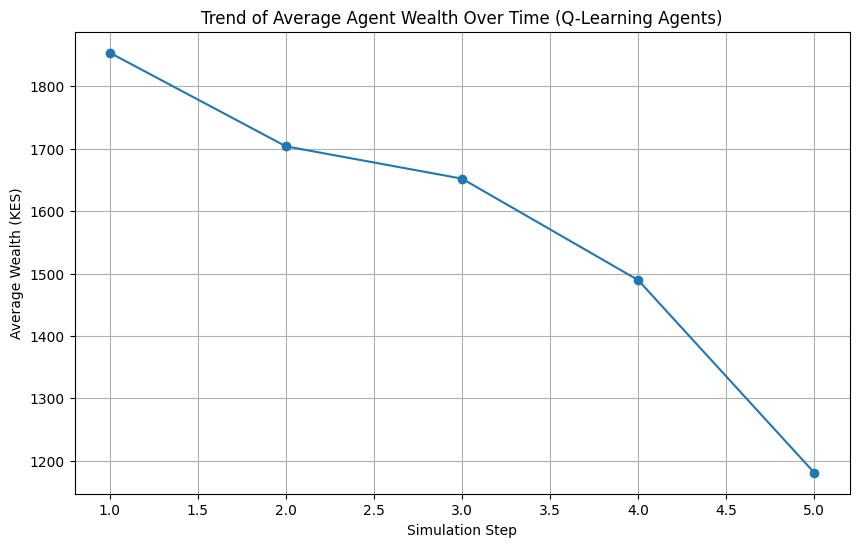

In [6]:
import matplotlib.pyplot as plt

external_global_data = [
    {'inflation_rate': 0.05, 'weather_condition': 'normal', 'tax_rate': 0.15, 'market_sentiment': 0.5},
    {'inflation_rate': 0.06, 'weather_condition': 'drought', 'tax_rate': 0.16, 'market_sentiment': 0.45},
    {'inflation_rate': 0.04, 'weather_condition': 'normal', 'tax_rate': 0.14, 'market_sentiment': 0.55},
    {'inflation_rate': 0.07, 'weather_condition': 'heavy_rains', 'tax_rate': 0.17, 'market_sentiment': 0.4},
    {'inflation_rate': 0.055, 'weather_condition': 'normal', 'tax_rate': 0.155, 'market_sentiment': 0.52}
]

# Re-initialize sim with QLearningAgents
sim_q_learning = Simulation(num_agents=3, initial_agent_wealth=2000)

print(f"\n--- Running Simulation with Q-Learning Agents and external data for {len(external_global_data)} steps ---")
sim_q_learning.run_simulation(external_global_data)

# Calculate and print the final average wealth of all Q-learning agents
total_wealth_q_learning = sum(agent.wealth for agent in sim_q_learning.agents)
average_wealth_q_learning = total_wealth_q_learning / len(sim_q_learning.agents)
print(f"\n--- Simulation Final Summary (Q-Learning Agents) ---")
print(f"Final Average Agent Wealth: KES {average_wealth_q_learning:.2f}")

# Plot the trend of average agent wealth for this new run with Q-learning agents
plt.figure(figsize=(10, 6))
plt.plot(range(1, sim_q_learning.time_step + 1), sim_q_learning.average_wealth_history, marker='o')
plt.title('Trend of Average Agent Wealth Over Time (Q-Learning Agents)')
plt.xlabel('Simulation Step')
plt.ylabel('Average Wealth (KES)')
plt.grid(True)
plt.show()

### Comparing Student's t-distribution vs. Normal Distribution for Financial Returns
Now let's address your second question regarding the choice of distribution for modeling financial returns. We will generate samples from both a Normal (Gaussian) distribution and a Student's t-distribution, and then visualize and compare their properties, particularly focusing on their tails.

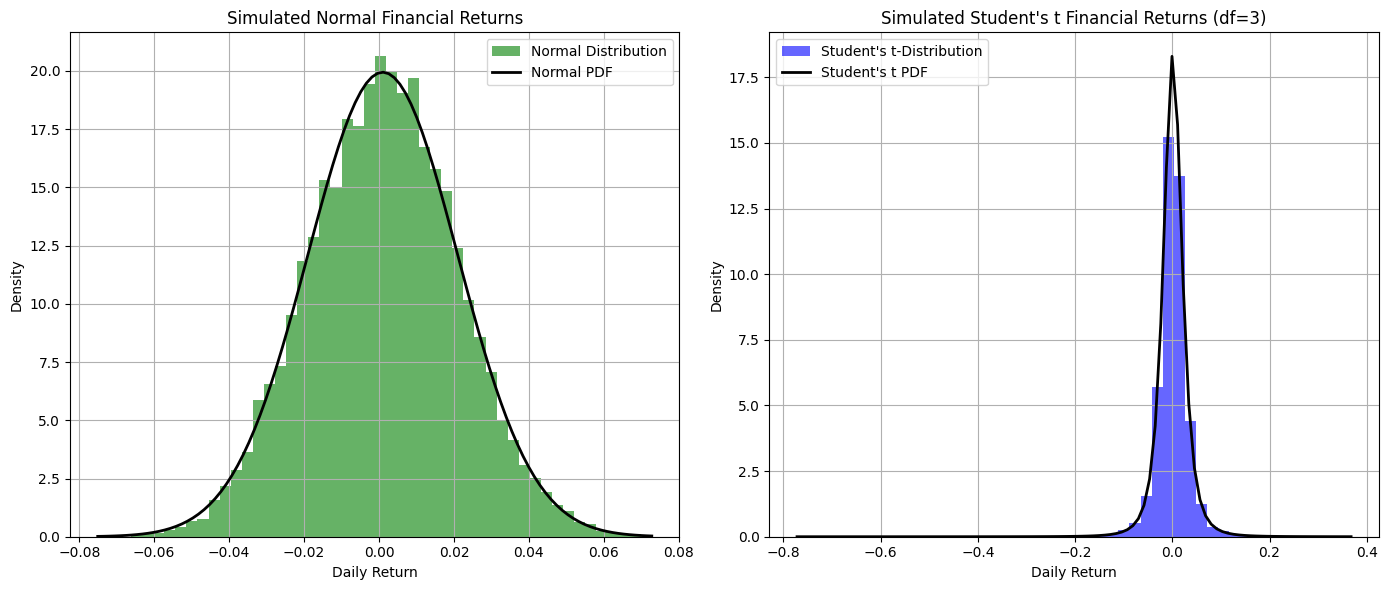

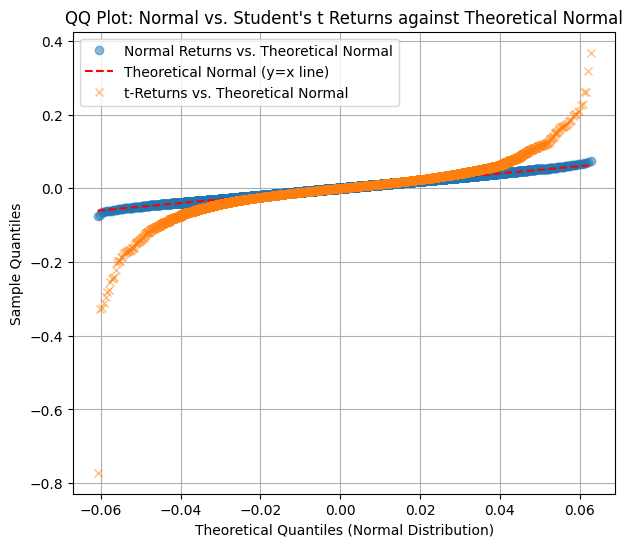


--- Descriptive Statistics ---
Normal Returns - Mean: 0.0012, Std Dev: 0.0198, Kurtosis (excess): -0.0333
Student's t Returns - Mean: 0.0007, Std Dev: 0.0348, Kurtosis (excess): 35.4781

Observation: Student's t-distribution (with low degrees of freedom) exhibits higher kurtosis, indicating fatter tails and more extreme values compared to the Normal distribution. This often makes it a better fit for real-world financial returns.


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, t

# Parameters for simulation
mu = 0.001       # Mean return
sigma = 0.02     # Standard deviation of returns
df_t = 3         # Degrees of freedom for Student's t-distribution (lower df means fatter tails)
num_samples = 10000 # Number of simulated daily returns

# 1. Generate samples from both distributions
normal_returns = norm.rvs(loc=mu, scale=sigma, size=num_samples)
t_returns = t.rvs(df=df_t, loc=mu, scale=sigma, size=num_samples)

# 2. Visualize the distributions with Histograms
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.hist(normal_returns, bins=50, density=True, alpha=0.6, color='g', label='Normal Distribution')
x = np.linspace(min(normal_returns), max(normal_returns), 100)
plt.plot(x, norm.pdf(x, loc=mu, scale=sigma), 'k-', lw=2, label='Normal PDF')
plt.title('Simulated Normal Financial Returns')
plt.xlabel('Daily Return')
plt.ylabel('Density')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.hist(t_returns, bins=50, density=True, alpha=0.6, color='b', label="Student's t-Distribution")
x = np.linspace(min(t_returns), max(t_returns), 100)
plt.plot(x, t.pdf(x, df=df_t, loc=mu, scale=sigma), 'k-', lw=2, label="Student's t PDF")
plt.title("Simulated Student's t Financial Returns (df=3)")
plt.xlabel('Daily Return')
plt.ylabel('Density')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 3. Quantile-Quantile (QQ) Plot to compare tails
plt.figure(figsize=(7, 6))

# Sort the sample returns for QQ plot
sorted_normal_returns = np.sort(normal_returns)
sorted_t_returns = np.sort(t_returns)

# Generate theoretical quantiles for the same number of samples
# Use np.linspace for probabilities (0 to 1) to get quantiles
probabilities = np.linspace(0.001, 0.999, num_samples) # Use num_samples points

theoretical_normal_quantiles = norm.ppf(probabilities, loc=mu, scale=sigma)
# The theoretical quantiles for the Student's t-distribution if we were to plot against itself
# theoretical_t_quantiles = t.ppf(probabilities, df=df_t, loc=mu, scale=sigma)

# QQ plot for Normal returns against theoretical normal
plt.plot(theoretical_normal_quantiles, sorted_normal_returns, 'o', alpha=0.5, label='Normal Returns vs. Theoretical Normal')
plt.plot(theoretical_normal_quantiles, theoretical_normal_quantiles, 'r--', label='Theoretical Normal (y=x line)')

# QQ plot for t-returns against theoretical normal to highlight fat tails
# We plot t_returns against a normal distribution to see how much it deviates from normality
plt.plot(theoretical_normal_quantiles, sorted_t_returns, 'x', alpha=0.5, label='t-Returns vs. Theoretical Normal')

plt.title('QQ Plot: Normal vs. Student\'s t Returns against Theoretical Normal')
plt.xlabel('Theoretical Quantiles (Normal Distribution)')
plt.ylabel('Sample Quantiles')
plt.legend()
plt.grid(True)
plt.show()

# 4. Calculate descriptive statistics (e.g., Kurtosis)
from scipy.stats import kurtosis

print("\n--- Descriptive Statistics ---")
print(f"Normal Returns - Mean: {np.mean(normal_returns):.4f}, Std Dev: {np.std(normal_returns):.4f}, Kurtosis (excess): {kurtosis(normal_returns):.4f}")
print(f"Student's t Returns - Mean: {np.mean(t_returns):.4f}, Std Dev: {np.std(t_returns):.4f}, Kurtosis (excess): {kurtosis(t_returns):.4f}")
print("\nObservation: Student's t-distribution (with low degrees of freedom) exhibits higher kurtosis, indicating fatter tails and more extreme values compared to the Normal distribution. This often makes it a better fit for real-world financial returns.")


In [8]:

sim = Simulation(num_agents=3, initial_agent_wealth=2000)
print(f"\n--- Running Simulation for a total of 12 steps (initial 2 + 10 more) ---")

# Define external global data for 12 steps
global_data_for_12_steps = [
    {'inflation_rate': 0.05, 'weather_condition': 'normal', 'tax_rate': 0.15, 'market_sentiment': 0.5},
    {'inflation_rate': 0.06, 'weather_condition': 'drought', 'tax_rate': 0.16, 'market_sentiment': 0.45},
    {'inflation_rate': 0.04, 'weather_condition': 'normal', 'tax_rate': 0.14, 'market_sentiment': 0.55},
    {'inflation_rate': 0.07, 'weather_condition': 'heavy_rains', 'tax_rate': 0.17, 'market_sentiment': 0.4},
    {'inflation_rate': 0.055, 'weather_condition': 'normal', 'tax_rate': 0.155, 'market_sentiment': 0.52},
    # Adding more steps to reach 12 total
    {'inflation_rate': 0.052, 'weather_condition': 'normal', 'tax_rate': 0.152, 'market_sentiment': 0.51},
    {'inflation_rate': 0.063, 'weather_condition': 'drought', 'tax_rate': 0.163, 'market_sentiment': 0.46},
    {'inflation_rate': 0.042, 'weather_condition': 'normal', 'tax_rate': 0.142, 'market_sentiment': 0.57},
    {'inflation_rate': 0.072, 'weather_condition': 'heavy_rains', 'tax_rate': 0.172, 'market_sentiment': 0.42},
    {'inflation_rate': 0.057, 'weather_condition': 'normal', 'tax_rate': 0.157, 'market_sentiment': 0.53},
    {'inflation_rate': 0.061, 'weather_condition': 'drought', 'tax_rate': 0.161, 'market_sentiment': 0.44},
    {'inflation_rate': 0.041, 'weather_condition': 'normal', 'tax_rate': 0.141, 'market_sentiment': 0.56}
]

sim.run_simulation(global_data_for_12_steps)


--- Running Simulation for a total of 12 steps (initial 2 + 10 more) ---

--- Simulation Step 1 ---
Global inflation rate updated to 5.00%
Global weather condition updated to: normal
Global tax rate updated to 15.00%
Global market sentiment updated to: 0.50

--- Global Economy Status ---
Inflation Rate: 5.00%
Weather Condition: normal
Tax Rate: 15.00%
Market Sentiment: 0.50
---------------------------
Agent KenyaCitizen_1 chose to: interact_bank. Received reward: 27.50
Agent KenyaCitizen_1 | Wealth: KES 1982.50 | Income: KES 300.00 | Market Sentiment: 0.50 | Health: injured | Employment: employed
  Current Q-values for state (1, 1, 1): [2.75 0.   0.  ]. Risk Score: 0.45
Agent KenyaCitizen_2 chose to: interact_bank. Received reward: 27.50
Agent KenyaCitizen_2 | Wealth: KES 1982.50 | Income: KES 300.00 | Market Sentiment: 0.50 | Health: injured | Employment: employed
  Current Q-values for state (1, 1, 1): [2.75 0.   0.  ]. Risk Score: 0.45
Agent KenyaCitizen_3 chose to: interact_bank. 

In [9]:
# Calculate and print the final average wealth of all agents
total_wealth = sum(agent.wealth for agent in sim.agents)
average_wealth = total_wealth / len(sim.agents)
print(f"\n--- Simulation Final Summary ---")
print(f"Final Average Agent Wealth: KES {average_wealth:.2f}")


--- Simulation Final Summary ---
Final Average Agent Wealth: KES 1566.39


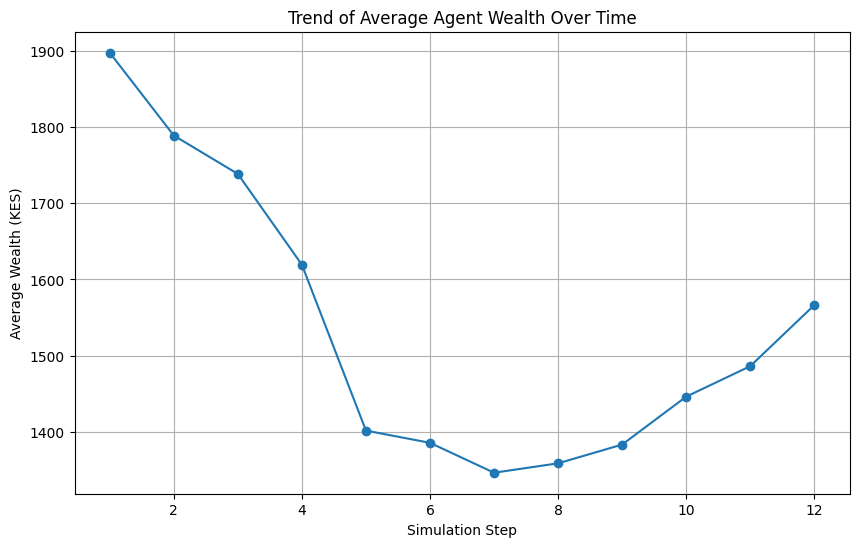

In [10]:
# Plot the trend of average agent wealth
plt.figure(figsize=(10, 6))
plt.plot(range(1, sim.time_step + 1), sim.average_wealth_history, marker='o')
plt.title('Trend of Average Agent Wealth Over Time')
plt.xlabel('Simulation Step')
plt.ylabel('Average Wealth (KES)')
plt.grid(True)
plt.show()


--- Running Simulation with external data for 5 steps ---

--- Simulation Step 1 ---
Global inflation rate updated to 5.00%
Global weather condition updated to: normal
Global tax rate updated to 15.00%
Global market sentiment updated to: 0.50

--- Global Economy Status ---
Inflation Rate: 5.00%
Weather Condition: normal
Tax Rate: 15.00%
Market Sentiment: 0.50
---------------------------
Agent KenyaCitizen_1 chose to: interact_bank. Received reward: 27.50
Agent KenyaCitizen_1 | Wealth: KES 1817.19 | Income: KES 300.00 | Market Sentiment: 0.50 | Health: sick | Employment: employed
  Current Q-values for state (1, 1, 1): [2.75 0.   0.  ]. Risk Score: 0.45
Agent KenyaCitizen_2 chose to: interact_bank. Received reward: 27.50
Agent KenyaCitizen_2 | Wealth: KES 1982.50 | Income: KES 300.00 | Market Sentiment: 0.50 | Health: injured | Employment: employed
  Current Q-values for state (1, 1, 1): [2.75 0.   0.  ]. Risk Score: 0.45
Agent KenyaCitizen_3 chose to: interact_bank. Received reward: 2

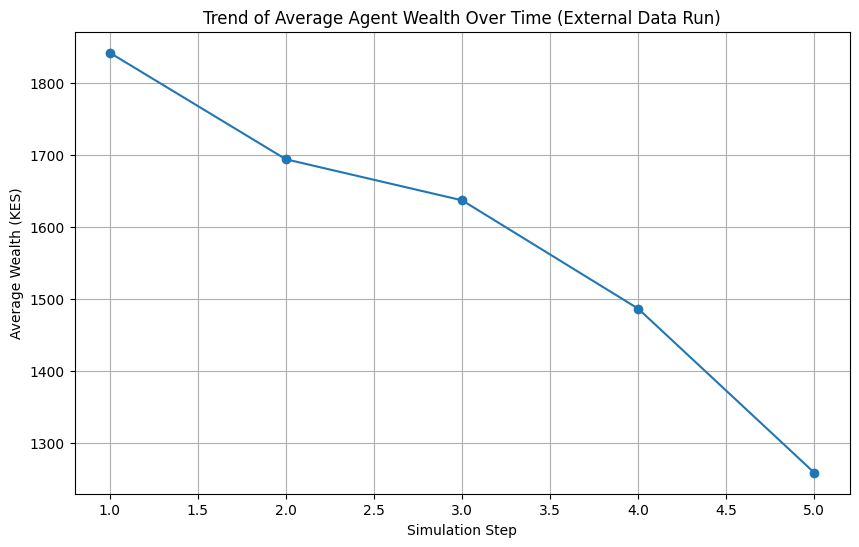

In [11]:
# Example of external data for simulation steps
# In a real-world scenario, this data would come from APIs, databases, or files.
external_global_data = [
    {'inflation_rate': 0.05, 'weather_condition': 'normal', 'tax_rate': 0.15, 'market_sentiment': 0.5},
    {'inflation_rate': 0.06, 'weather_condition': 'drought', 'tax_rate': 0.16, 'market_sentiment': 0.45},
    {'inflation_rate': 0.04, 'weather_condition': 'normal', 'tax_rate': 0.14, 'market_sentiment': 0.55},
    {'inflation_rate': 0.07, 'weather_condition': 'heavy_rains', 'tax_rate': 0.17, 'market_sentiment': 0.4},
    {'inflation_rate': 0.055, 'weather_condition': 'normal', 'tax_rate': 0.155, 'market_sentiment': 0.52}
]

sim = Simulation(num_agents=3, initial_agent_wealth=2000)

print(f"\n--- Running Simulation with external data for {len(external_global_data)} steps ---")
sim.run_simulation(external_global_data)

# Calculate and print the final average wealth of all agents
total_wealth_new_run = sum(agent.wealth for agent in sim.agents)
average_wealth_new_run = total_wealth_new_run / len(sim.agents)
print(f"\n--- Simulation Final Summary (External Data Run) ---")
print(f"Final Average Agent Wealth: KES {average_wealth_new_run:.2f}")

# Plot the trend of average agent wealth
plt.figure(figsize=(10, 6))
plt.plot(range(1, sim.time_step + 1), sim.average_wealth_history, marker='o')
plt.title('Trend of Average Agent Wealth Over Time (External Data Run)')
plt.xlabel('Simulation Step')
plt.ylabel('Average Wealth (KES)')
plt.grid(True)
plt.show()

### Integrating Real-World-like Data from a CSV

To simulate real-world data integration, we'll first create a dummy CSV file that contains global economic parameters for several simulation steps. In a real scenario, this data could come from financial APIs, government reports, or other external databases.

In [12]:
import pandas as pd

# Create a dummy CSV file with more varied and extended global data
dummy_data = [
    {'inflation_rate': 0.04, 'weather_condition': 'normal', 'tax_rate': 0.14, 'market_sentiment': 0.6},
    {'inflation_rate': 0.05, 'weather_condition': 'normal', 'tax_rate': 0.15, 'market_sentiment': 0.55},
    {'inflation_rate': 0.06, 'weather_condition': 'drought', 'tax_rate': 0.16, 'market_sentiment': 0.45},
    {'inflation_rate': 0.045, 'weather_condition': 'normal', 'tax_rate': 0.145, 'market_sentiment': 0.58},
    {'inflation_rate': 0.07, 'weather_condition': 'heavy_rains', 'tax_rate': 0.17, 'market_sentiment': 0.4},
    {'inflation_rate': 0.05, 'weather_condition': 'normal', 'tax_rate': 0.15, 'market_sentiment': 0.5},
    {'inflation_rate': 0.055, 'weather_condition': 'normal', 'tax_rate': 0.155, 'market_sentiment': 0.52},
    {'inflation_rate': 0.065, 'weather_condition': 'drought', 'tax_rate': 0.165, 'market_sentiment': 0.42},
    {'inflation_rate': 0.042, 'weather_condition': 'normal', 'tax_rate': 0.142, 'market_sentiment': 0.62},
    {'inflation_rate': 0.075, 'weather_condition': 'heavy_rains', 'tax_rate': 0.175, 'market_sentiment': 0.38},
    {'inflation_rate': 0.048, 'weather_condition': 'normal', 'tax_rate': 0.148, 'market_sentiment': 0.59},
    {'inflation_rate': 0.058, 'weather_condition': 'normal', 'tax_rate': 0.158, 'market_sentiment': 0.51},
    {'inflation_rate': 0.062, 'weather_condition': 'drought', 'tax_rate': 0.162, 'market_sentiment': 0.47},
    {'inflation_rate': 0.041, 'weather_condition': 'normal', 'tax_rate': 0.141, 'market_sentiment': 0.61},
    {'inflation_rate': 0.071, 'weather_condition': 'heavy_rains', 'tax_rate': 0.171, 'market_sentiment': 0.39}
]

df_global_data = pd.DataFrame(dummy_data)
df_global_data.to_csv('global_economy_data.csv', index=False)

print("Generated 'global_economy_data.csv' with 15 steps of data.")
print("Displaying head of the DataFrame:")
display(df_global_data.head())

Generated 'global_economy_data.csv' with 15 steps of data.
Displaying head of the DataFrame:


,inflation_rate,weather_condition,tax_rate,market_sentiment
0,0.040,normal,0.140,0.60
1,0.050,normal,0.150,0.55
2,0.060,drought,0.160,0.45
3,0.045,normal,0.145,0.58
4,0.070,heavy_rains,0.170,0.40


### Loading and Using the CSV Data for Simulation

Now we'll load this CSV data into a list of dictionaries, which our `Simulation` class expects, and run another simulation to see how the agents react to this new sequence of economic conditions.


--- Running Simulation with CSV data for 15 steps ---

--- Simulation Step 1 ---
Global inflation rate updated to 4.00%
Global weather condition updated to: normal
Global tax rate updated to 14.00%
Global market sentiment updated to: 0.60

--- Global Economy Status ---
Inflation Rate: 4.00%
Weather Condition: normal
Tax Rate: 14.00%
Market Sentiment: 0.60
---------------------------
Agent KenyaCitizen_1 chose to: interact_bank. Received reward: 28.00
Agent KenyaCitizen_1 | Wealth: KES 1848.16 | Income: KES 300.00 | Market Sentiment: 0.50 | Health: sick | Employment: employed
  Current Q-values for state (1, 1, 1): [2.8 0.  0. ]. Risk Score: 0.45
Agent KenyaCitizen_2 chose to: interact_bank. Received reward: 28.00
Agent KenyaCitizen_2 | Wealth: KES 1645.31 | Income: KES 0.00 | Market Sentiment: 0.50 | Health: sick | Employment: unemployed
  Current Q-values for state (0, 1, 1): [2.8 0.  0. ]. Risk Score: 0.65
Agent KenyaCitizen_3 chose to: interact_bank. Received reward: 28.00
Agent Ke

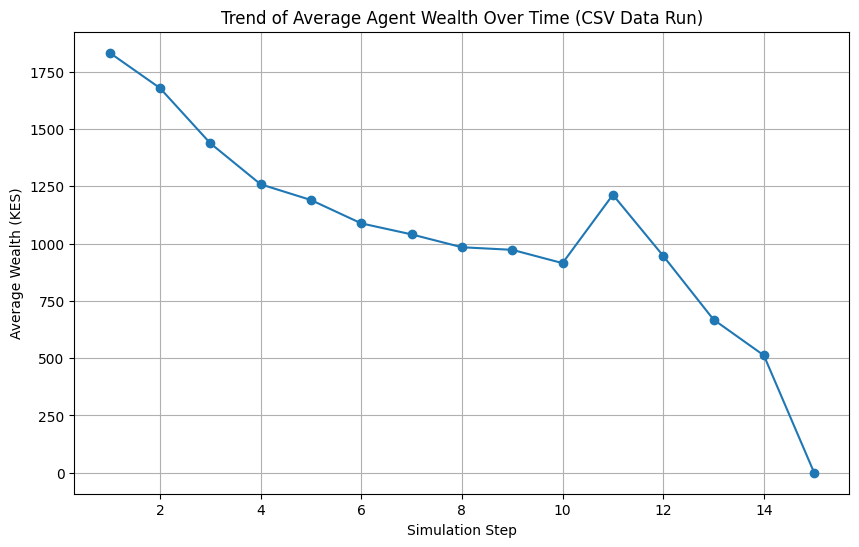

In [13]:
# Load the data from the generated CSV file
loaded_global_data_df = pd.read_csv('global_economy_data.csv')

# Convert DataFrame rows to a list of dictionaries, as expected by run_simulation
real_world_simulation_data = loaded_global_data_df.to_dict(orient='records')

# Re-initialize sim with QLearningAgents for a fresh run
sim_real_world = Simulation(num_agents=3, initial_agent_wealth=2000, default_threshold=500) # Set a default threshold

print(f"\n--- Running Simulation with CSV data for {len(real_world_simulation_data)} steps ---")
sim_real_world.run_simulation(real_world_simulation_data)

# Calculate and print the final average wealth of all Q-learning agents
total_wealth_real_world = sum(agent.wealth for agent in sim_real_world.agents)
average_wealth_real_world = total_wealth_real_world / len(sim_real_world.agents)
print(f"\n--- Simulation Final Summary (CSV Data Run) ---")
print(f"Final Average Agent Wealth: KES {average_wealth_real_world:.2f}")

# Plot the trend of average agent wealth for this run
plt.figure(figsize=(10, 6))
plt.plot(range(1, sim_real_world.time_step + 1), sim_real_world.average_wealth_history, marker='o')
plt.title('Trend of Average Agent Wealth Over Time (CSV Data Run)')
plt.xlabel('Simulation Step')
plt.ylabel('Average Wealth (KES)')
plt.grid(True)
plt.show()

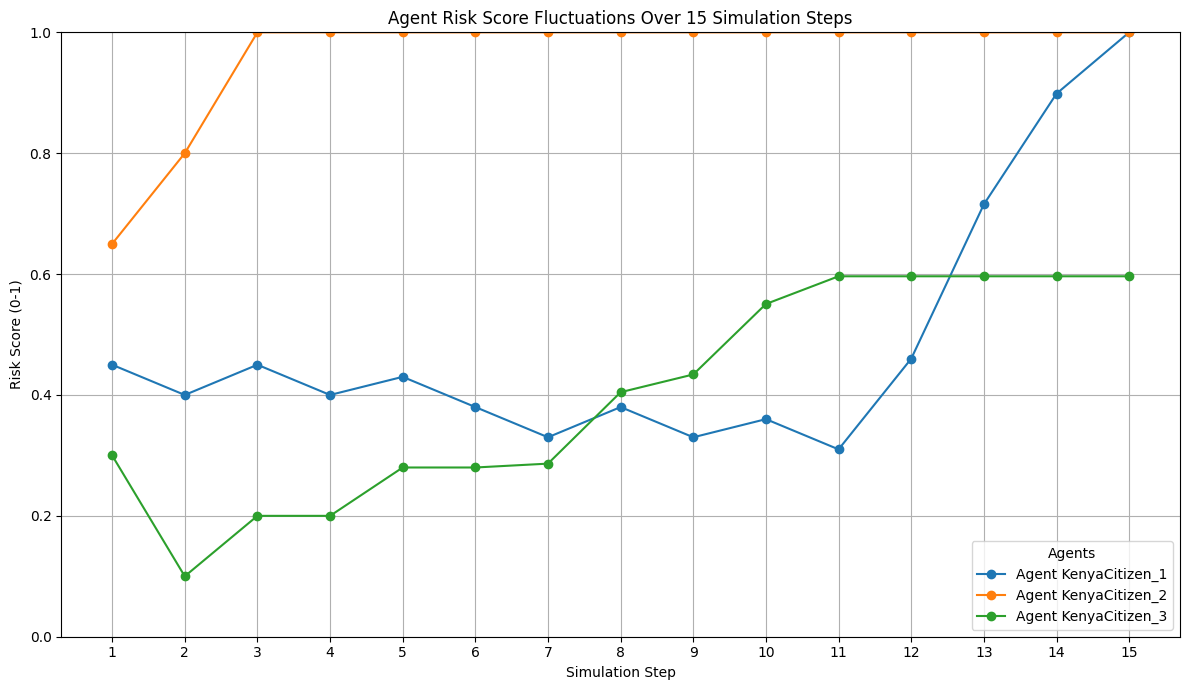

In [14]:
import matplotlib.pyplot as plt

# Plot the fluctuation of agent risk scores
plt.figure(figsize=(12, 7))

# Iterate through each agent's risk score history and plot it
for agent_id, risk_scores in sim_real_world.risk_score_history.items():
    # Ensure the length matches the simulation steps
    # If an agent defaulted, their last known risk score was appended repeatedly.
    # So, we just plot the recorded history.
    plt.plot(range(1, len(risk_scores) + 1), risk_scores, marker='o', linestyle='-', label=f'Agent {agent_id}')

plt.title('Agent Risk Score Fluctuations Over 15 Simulation Steps')
plt.xlabel('Simulation Step')
plt.ylabel('Risk Score (0-1)')
plt.ylim(0, 1) # Risk score is between 0 and 1
plt.xticks(range(1, 16)) # Ensure all 15 steps are visible on x-axis
plt.grid(True)
plt.legend(title='Agents')
plt.tight_layout()
plt.show()

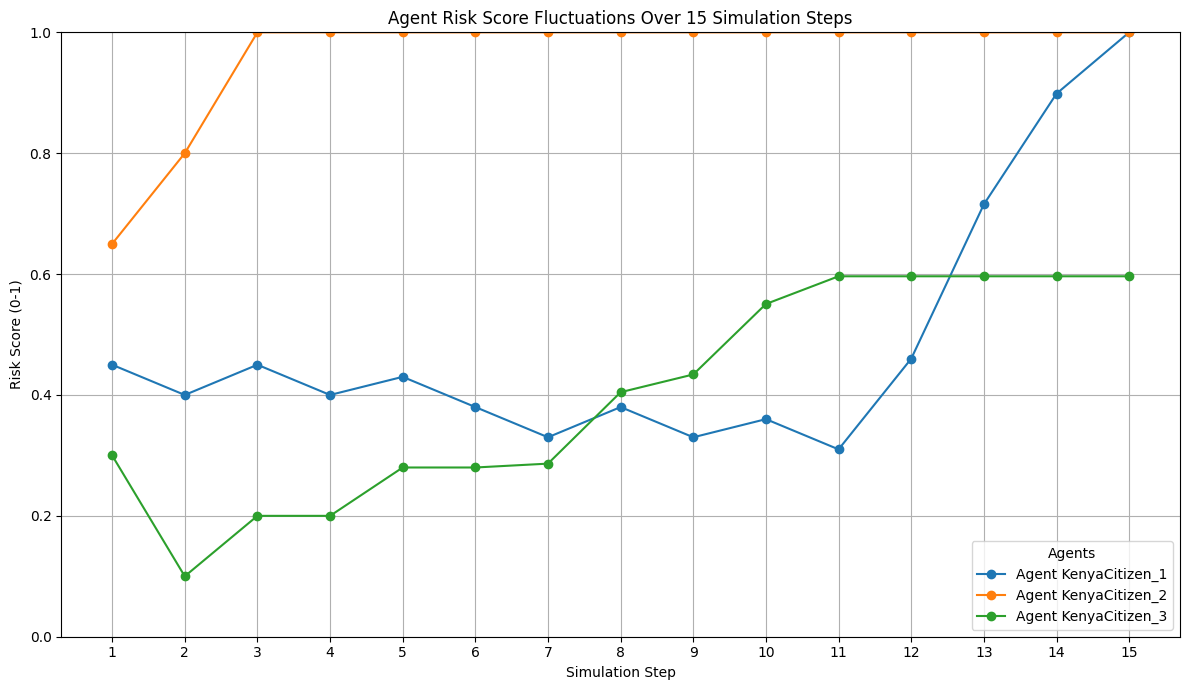

In [15]:
import matplotlib.pyplot as plt

# Plot the fluctuation of agent risk scores
plt.figure(figsize=(12, 7))

# Iterate through each agent's risk score history and plot it
for agent_id, risk_scores in sim_real_world.risk_score_history.items():
    # If an agent defaulted, their last known risk score was appended repeatedly.
    # So, we just plot the recorded history.
    plt.plot(range(1, len(risk_scores) + 1), risk_scores, marker='o', linestyle='-', label=f'Agent {agent_id}')

plt.title('Agent Risk Score Fluctuations Over 15 Simulation Steps')
plt.xlabel('Simulation Step')
plt.ylabel('Risk Score (0-1)')
plt.ylim(0, 1) # Risk score is between 0 and 1
plt.xticks(range(1, 16)) # Ensure all 15 steps are visible on x-axis
plt.grid(True)
plt.legend(title='Agents')
plt.tight_layout()
plt.show()


--- Analyzing Default Threshold Impact ---
Running simulation with default_threshold = 100 KES

--- Simulation Step 1 ---
Global inflation rate updated to 4.00%
Global weather condition updated to: normal
Global tax rate updated to 14.00%
Global market sentiment updated to: 0.60

--- Global Economy Status ---
Inflation Rate: 4.00%
Weather Condition: normal
Tax Rate: 14.00%
Market Sentiment: 0.60
---------------------------
Agent KenyaCitizen_1 chose to: interact_bank. Received reward: 28.00
Agent KenyaCitizen_1 is now UNEMPLOYED. Income: 0 KES.
Agent KenyaCitizen_1 | Wealth: KES 1904.64 | Income: KES 0.00 | Market Sentiment: 0.50 | Health: sick | Employment: unemployed
  Current Q-values for state (0, 1, 1): [0. 0. 0.]. Risk Score: 0.45
Agent KenyaCitizen_2 chose to: interact_bank. Received reward: 28.00
Agent KenyaCitizen_2 | Wealth: KES 1748.00 | Income: KES 0.00 | Market Sentiment: 0.50 | Health: healthy | Employment: unemployed
  Current Q-values for state (0, 0, 1): [2.8 0.  0. ]

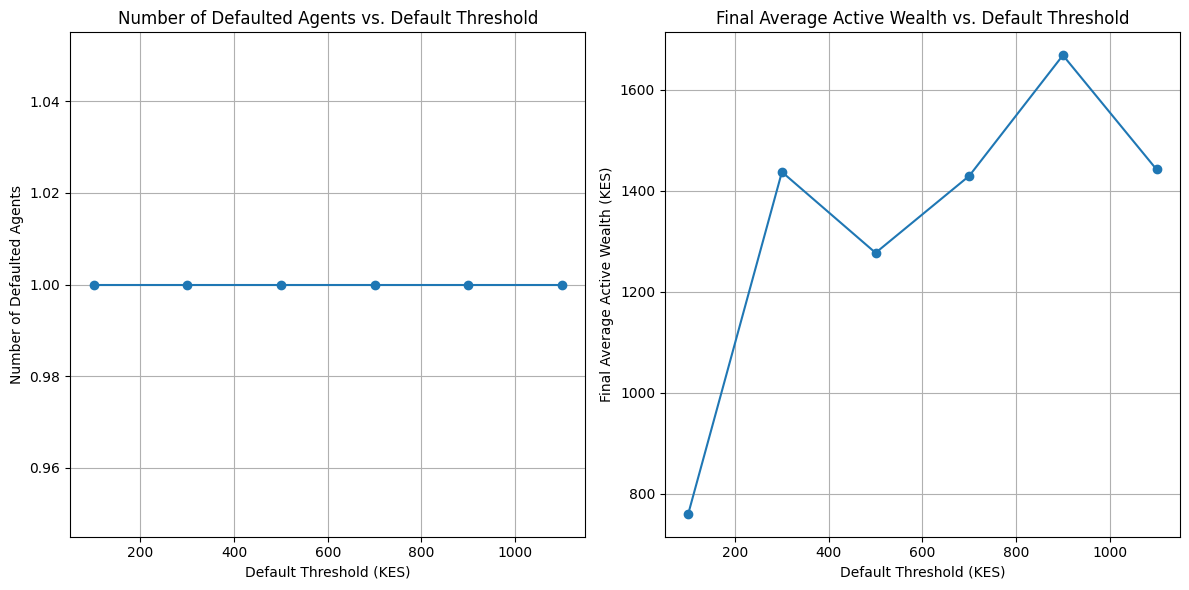

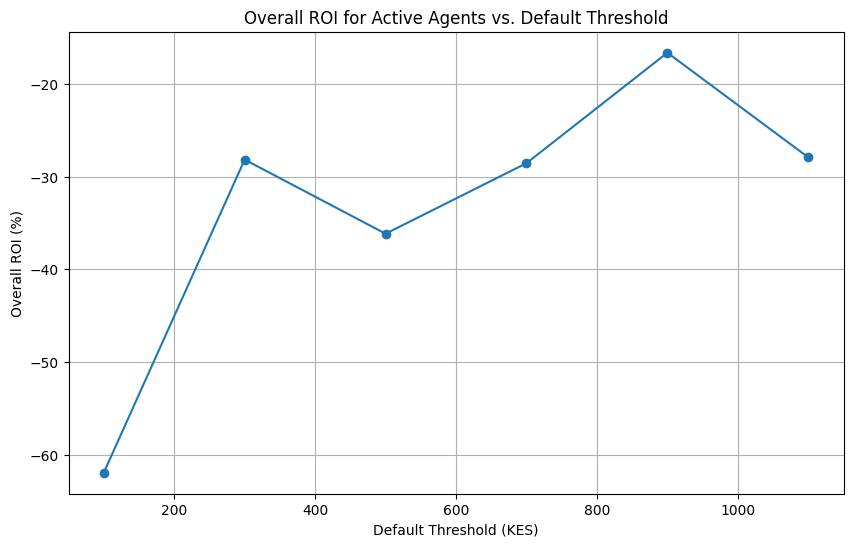

In [16]:
def run_simulation_with_threshold(default_threshold, simulation_data, num_agents=3, initial_agent_wealth=2000):
    sim = Simulation(num_agents=num_agents, initial_agent_wealth=initial_agent_wealth, default_threshold=default_threshold)
    sim.run_simulation(simulation_data)

    overall_roi, individual_rois = sim.calculate_long_term_roi()
    num_defaulted = len(sim.defaulted_agents)
    final_active_agents_wealth = sum(agent.wealth for agent in sim.agents if agent.agent_id not in sim.defaulted_agents)
    num_active_agents = len([agent for agent in sim.agents if agent.agent_id not in sim.defaulted_agents])
    final_average_active_wealth = final_active_agents_wealth / num_active_agents if num_active_agents > 0 else 0

    return {
        'default_threshold': default_threshold,
        'num_defaulted_agents': num_defaulted,
        'final_average_active_wealth': final_average_active_wealth,
        'overall_roi_active_agents': overall_roi,
        'average_wealth_history': sim.average_wealth_history
    }

# Define a range of default thresholds to test
threshold_values = [100, 300, 500, 700, 900, 1100]

simulation_results = []

print("\n--- Analyzing Default Threshold Impact ---")
# Use the real_world_simulation_data from the CSV for consistency
for threshold in threshold_values:
    print(f"Running simulation with default_threshold = {threshold} KES")
    result = run_simulation_with_threshold(threshold, real_world_simulation_data)
    simulation_results.append(result)
    print("------------------------------------------")

# Display summary of results
print("\n--- Default Threshold Analysis Summary ---")
for res in simulation_results:
    print(f"Threshold: {res['default_threshold']} KES | Defaulted Agents: {res['num_defaulted_agents']} | Final Avg Active Wealth: {res['final_average_active_wealth']:.2f} KES | Overall ROI (Active): {res['overall_roi_active_agents']:.2f}%")

# Optional: Visualize the impact
plt.figure(figsize=(12, 6))

# Plot Number of Defaulted Agents vs. Threshold
plt.subplot(1, 2, 1)
thresholds = [res['default_threshold'] for res in simulation_results]
num_defaulted = [res['num_defaulted_agents'] for res in simulation_results]
plt.plot(thresholds, num_defaulted, marker='o', linestyle='-')
plt.title('Number of Defaulted Agents vs. Default Threshold')
plt.xlabel('Default Threshold (KES)')
plt.ylabel('Number of Defaulted Agents')
plt.grid(True)

# Plot Final Average Active Wealth vs. Threshold
plt.subplot(1, 2, 2)
final_avg_wealth = [res['final_average_active_wealth'] for res in simulation_results]
plt.plot(thresholds, final_avg_wealth, marker='o', linestyle='-')
plt.title('Final Average Active Wealth vs. Default Threshold')
plt.xlabel('Default Threshold (KES)')
plt.ylabel('Final Average Active Wealth (KES)')
plt.grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
# Plot Overall ROI (Active Agents) vs. Threshold
overall_roi_active = [res['overall_roi_active_agents'] for res in simulation_results]
plt.plot(thresholds, overall_roi_active, marker='o', linestyle='-')
plt.title('Overall ROI for Active Agents vs. Default Threshold')
plt.xlabel('Default Threshold (KES)')
plt.ylabel('Overall ROI (%)')
plt.grid(True)
plt.show()


--- Analyzing Default Threshold Impact ---
Running simulation with default_threshold = 100 KES

--- Simulation Step 1 ---
Global inflation rate updated to 4.00%
Global weather condition updated to: normal
Global tax rate updated to 14.00%
Global market sentiment updated to: 0.60

--- Global Economy Status ---
Inflation Rate: 4.00%
Weather Condition: normal
Tax Rate: 14.00%
Market Sentiment: 0.60
---------------------------
Agent KenyaCitizen_1 chose to: interact_bank. Received reward: 28.00
Agent KenyaCitizen_1 | Wealth: KES 1748.00 | Income: KES 0.00 | Market Sentiment: 0.50 | Health: injured | Employment: unemployed
  Current Q-values for state (0, 1, 1): [2.8 0.  0. ]. Risk Score: 0.65
Agent KenyaCitizen_2 chose to: interact_bank. Received reward: 28.00
Agent KenyaCitizen_2 | Wealth: KES 1748.00 | Income: KES 0.00 | Market Sentiment: 0.50 | Health: healthy | Employment: unemployed
  Current Q-values for state (0, 0, 1): [2.8 0.  0. ]. Risk Score: 0.50
Agent KenyaCitizen_3 chose to:

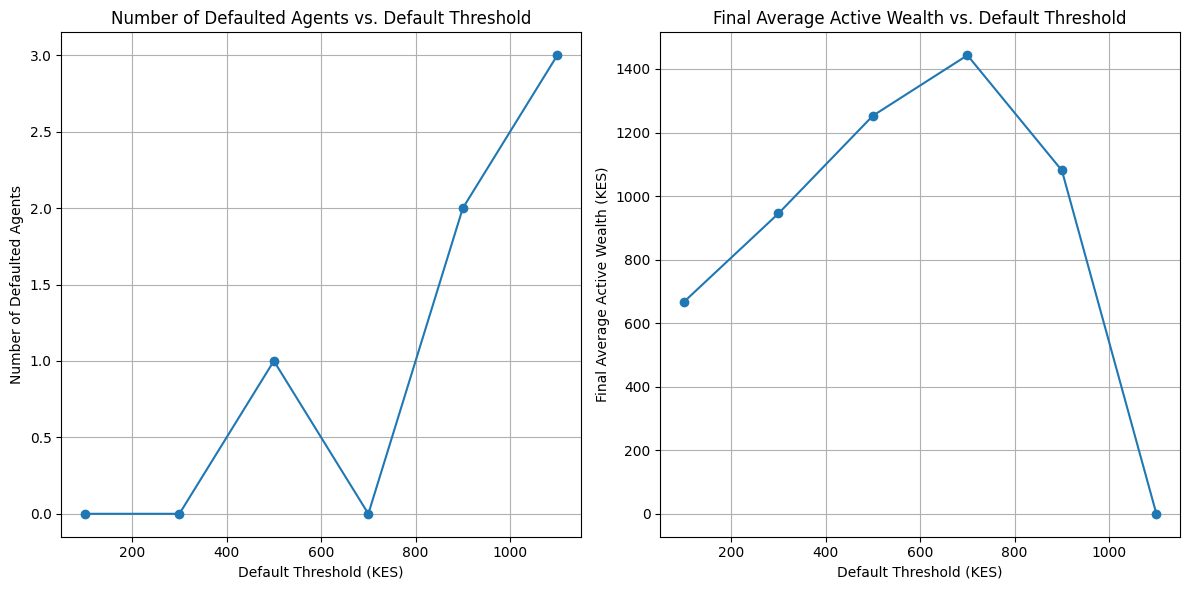

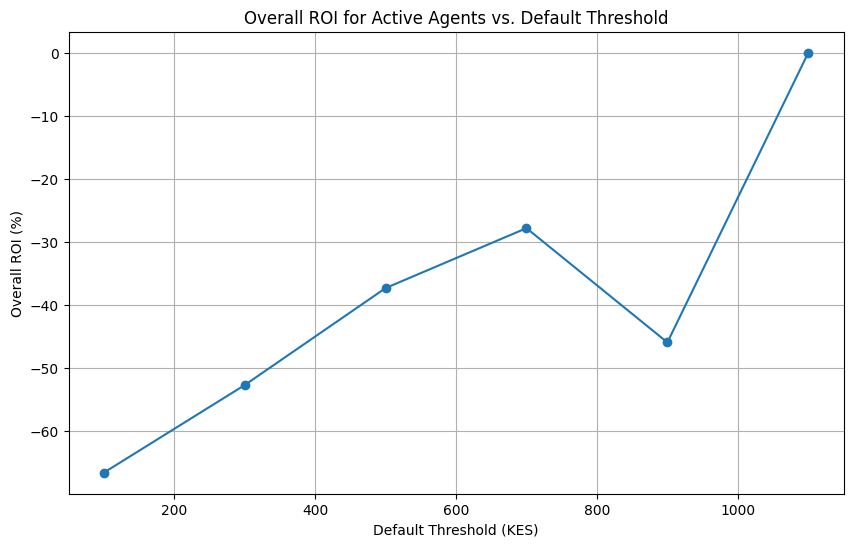

In [17]:
def run_simulation_with_threshold(default_threshold, simulation_data, num_agents=3, initial_agent_wealth=2000):
    sim = Simulation(num_agents=num_agents, initial_agent_wealth=initial_agent_wealth, default_threshold=default_threshold)
    sim.run_simulation(simulation_data)

    overall_roi, individual_rois = sim.calculate_long_term_roi()
    num_defaulted = len(sim.defaulted_agents)
    final_active_agents_wealth = sum(agent.wealth for agent in sim.agents if agent.agent_id not in sim.defaulted_agents)
    num_active_agents = len([agent for agent in sim.agents if agent.agent_id not in sim.defaulted_agents])
    final_average_active_wealth = final_active_agents_wealth / num_active_agents if num_active_agents > 0 else 0

    return {
        'default_threshold': default_threshold,
        'num_defaulted_agents': num_defaulted,
        'final_average_active_wealth': final_average_active_wealth,
        'overall_roi_active_agents': overall_roi,
        'average_wealth_history': sim.average_wealth_history
    }

# Define a range of default thresholds to test
threshold_values = [100, 300, 500, 700, 900, 1100]

simulation_results = []

print("\n--- Analyzing Default Threshold Impact ---")
# Use the real_world_simulation_data from the CSV for consistency
for threshold in threshold_values:
    print(f"Running simulation with default_threshold = {threshold} KES")
    result = run_simulation_with_threshold(threshold, real_world_simulation_data)
    simulation_results.append(result)
    print("------------------------------------------")

# Display summary of results
print("\n--- Default Threshold Analysis Summary ---")
for res in simulation_results:
    print(f"Threshold: {res['default_threshold']} KES | Defaulted Agents: {res['num_defaulted_agents']} | Final Avg Active Wealth: {res['final_average_active_wealth']:.2f} KES | Overall ROI (Active): {res['overall_roi_active_agents']:.2f}%")

# Visualize the impact
plt.figure(figsize=(12, 6))

# Plot Number of Defaulted Agents vs. Threshold
plt.subplot(1, 2, 1)
thresholds = [res['default_threshold'] for res in simulation_results]
num_defaulted = [res['num_defaulted_agents'] for res in simulation_results]
plt.plot(thresholds, num_defaulted, marker='o', linestyle='-')
plt.title('Number of Defaulted Agents vs. Default Threshold')
plt.xlabel('Default Threshold (KES)')
plt.ylabel('Number of Defaulted Agents')
plt.grid(True)

# Plot Final Average Active Wealth vs. Threshold
plt.subplot(1, 2, 2)
final_avg_wealth = [res['final_average_active_wealth'] for res in simulation_results]
plt.plot(thresholds, final_avg_wealth, marker='o', linestyle='-')
plt.title('Final Average Active Wealth vs. Default Threshold')
plt.xlabel('Default Threshold (KES)')
plt.ylabel('Final Average Active Wealth (KES)')
plt.grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
# Plot Overall ROI (Active Agents) vs. Threshold
overall_roi_active = [res['overall_roi_active_agents'] for res in simulation_results]
plt.plot(thresholds, overall_roi_active, marker='o', linestyle='-')
plt.title('Overall ROI for Active Agents vs. Default Threshold')
plt.xlabel('Default Threshold (KES)')
plt.ylabel('Overall ROI (%)')
plt.grid(True)
plt.show()

## Facial Recognition: Setting Up the Environment

To begin with facial recognition, we'll install a popular Python library called `face_recognition`. This library is built on top of `dlib`'s state-of-the-art face recognition models and provides a simple API for common tasks like face detection, face landmark detection, and face encoding.

Keep in mind that for 'millions of faces,' we'd eventually need more optimized solutions like batch processing, distributed systems, and specialized hardware (GPUs/TPUs), but this library is a great starting point for understanding the core concepts and can handle a significant amount of data.

In [1]:
# Install the face_recognition library
# This might take a few minutes as it compiles dlib.
!pip install face_recognition opencv-python numpy matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 8.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566242 sha256=629efa8a8777b84ca0ecca58b67a6155e12d1b8b76ce27e2428d9dbae6a31e34
  Stored in directory: /root/.cache/pip/wheels/39/20/47/6b647a3457f0e36c161b2516a5bd7f29f6bbd5e3a67c46a710
Successfully built face-recognition-models


In [ ]:
import face_recognition
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow # For displaying images in Colab
import numpy as np
import requests
from PIL import Image
import io

# Function to download an image from a URL
def download_image(url, filename):
    response = requests.get(url)
    response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
    with open(filename, 'wb') as f:
        f.write(response.content)
    print(f"Downloaded image to '{filename}'")

# Public domain image URL
image_url = "https://images.unsplash.com/photo-1544005313-94ddf0286df2?q=80&w=1976&auto=format&fit=crop&ixlib=rb-4.0.3&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D"
image_filename = "portrait.jpg"

# Download the image
try:
    download_image(image_url, image_filename)
except requests.exceptions.RequestException as e:
    print(f"Error downloading image: {e}. Please check the URL or your internet connection.")
    # If download fails, we cannot proceed with face detection meaningfully without a real face.
    # Display an error image and exit gracefully.
    img = np.zeros((300, 400, 3), dtype=np.uint8)
    cv2.putText(img, "Image download failed!", (50, 150), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
    cv2.imwrite(image_filename, img)
    image_with_faces = img # Assign the error image for display
    cv2_imshow(image_with_faces)
    print("Face detection skipped due to download error.")
    exit()



# Load the image using face_recognition
image = face_recognition.load_image_file(image_filename)

# Find all face locations (bounding boxes) in the image
face_locations = face_recognition.face_locations(image)

print(f"Found {len(face_locations)} face(s) in the image.")

# Draw bounding boxes around the faces and display the image
image_with_faces = cv2.imread(image_filename)

if image_with_faces is None:
    print(f"Error: Could not load image from {image_filename}. It might be corrupted or not exist.")
else:
    for top, right, bottom, left in face_locations:
        # Draw a box around the face
        cv2.rectangle(image_with_faces, (left, top), (right, bottom), (0, 255, 0), 2) # Green rectangle

    # Display the image in Colab
    cv2_imshow(image_with_faces)


/usr/local/lib/python3.13/dist-packages/face_recognition_models/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


Downloaded image to 'portrait.jpg'
Found 1 face(s) in the image.


### Face Encoding and Comparison

Once faces are detected, the next step in facial recognition is to extract **face encodings**. These are 128-dimensional vectors that represent the unique features of a face. They are often called "face fingerprints" because they are highly distinctive for each individual.

After obtaining encodings, you can compare them to determine if two faces belong to the same person. We'll demonstrate this by encoding the face from our `portrait.jpg` and comparing it to itself to show a successful match.


In [ ]:
# Load the image
image = face_recognition.load_image_file(image_filename)

# Get the face encodings. If there are multiple faces, it will return a list of encodings.
face_encodings = face_recognition.face_encodings(image)

if len(face_encodings) > 0:
    # Take the first face encoding found in the image
    known_face_encoding = face_encodings[0]
    print(f"Extracted encoding for the known face. Length: {len(known_face_encoding)}")

    # For demonstration, let's use the same image's encoding as the 'unknown' face
    # In a real scenario, this would be an encoding from a different image you want to identify.
    # Let's assume we have another image of the same person, or just re-encode the same face for a guaranteed match.

    # To simulate an 'unknown' face, we will re-process the same image
    unknown_image = face_recognition.load_image_file(image_filename) # Or another image like 'unknown_person.jpg'
    unknown_face_encodings = face_recognition.face_encodings(unknown_image)

    if len(unknown_face_encodings) > 0:
        unknown_face_encoding = unknown_face_encodings[0]
        print(f"Extracted encoding for the unknown face. Length: {len(unknown_face_encoding)}")

        # Compare the known face encoding with the unknown face encoding
        # `compare_faces` returns a list of booleans, indicating if each known face matches the unknown face.
        # Since we are comparing one known face to one unknown face, the list will have one element.
        tolerance = 0.6 # Lower tolerance means stricter match
        results = face_recognition.compare_faces([known_face_encoding], unknown_face_encoding, tolerance=tolerance)

        if results[0]:
            print(f"MATCH! The faces are a match within a tolerance of {tolerance}.")
        else:
            print(f"NO MATCH. The faces do not match within a tolerance of {tolerance}.")

        # You can also get the face distance, a measure of similarity (lower is better)
        face_distance = face_recognition.face_distance([known_face_encoding], unknown_face_encoding)
        print(f"Face distance: {face_distance[0]:.4f} (lower is better, typically below 0.6 for a match).")

    else:
        print("No face found in the unknown image for encoding.")
else:
    print("No face found in the known image for encoding.")


### Comparing Two Different Faces

To demonstrate a more practical scenario, we will now compare the face from `portrait.jpg` with a face from another image, `portrait_woman.jpg`. This will show how the algorithm determines if two different pictures belong to the same individual based on their face encodings and a set tolerance.

In [ ]:
import requests
import os

def download_image(url, filename):
    try:
        response = requests.get(url, stream=True)
        response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
        with open(filename, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        print(f"Downloaded image to '{filename}'")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading image {filename}: {e}")
        from PIL import Image
        img = Image.new('RGB', (60, 30), color = 'red')
        img.save(filename)
        print(f"Created a dummy red image for '{filename}' due to download failure.")

# Public domain image URL for a different face
image_woman_url = "https://images.unsplash.com/photo-1570295999919-56ceb5ecca61?q=80&w=200&auto=format&fit=crop&ixlib=rb-4.0.3&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D"
image_woman_filename = "portrait_woman.jpg"

# Download the second image
download_image(image_woman_url, image_woman_filename)

In [ ]:
import face_recognition
import numpy as np

# Assuming 'portrait.jpg' contains the known face
known_image = face_recognition.load_image_file("portrait.jpg")
known_face_encodings = face_recognition.face_encodings(known_image)

# Assuming 'portrait_woman.jpg' contains another face we want to compare
unknown_image_2 = face_recognition.load_image_file("portrait_woman.jpg")
unknown_face_encodings_2 = face_recognition.face_encodings(unknown_image_2)

if len(known_face_encodings) > 0 and len(unknown_face_encodings_2) > 0:
    known_face_encoding_1 = known_face_encodings[0]
    unknown_face_encoding_2 = unknown_face_encodings_2[0]

    print(f"Extracted encoding for known face (portrait.jpg). Length: {len(known_face_encoding_1)}")
    print(f"Extracted encoding for unknown face (portrait_woman.jpg). Length: {len(unknown_face_encoding_2)}")

    tolerance = 0.6
    results = face_recognition.compare_faces([known_face_encoding_1], unknown_face_encoding_2, tolerance=tolerance)

    if results[0]:
        print(f"MATCH! The faces are a match within a tolerance of {tolerance}.")
    else:
        print(f"NO MATCH. The faces do not match within a tolerance of {tolerance}.")

    # Get the actual face distance
    # Lower distance indicates higher similarity. A distance of 0 means identical.
    face_distance_val = face_recognition.face_distance([known_face_encoding_1], unknown_face_encoding_2)
    print(f"Face distance: {face_distance_val[0]:.4f} (lower is better, typically below {tolerance} for a match). (Different faces will usually be > 0.6)")

else:
    print("Could not find faces in one or both of the images for comparison after re-download.")

In [ ]:
import face_recognition
import numpy as np

# Assuming 'portrait.jpg' contains the known face
known_image = face_recognition.load_image_file("portrait.jpg")
known_face_encodings = face_recognition.face_encodings(known_image)

# Assuming 'portrait_woman.jpg' contains another face we want to compare
unknown_image_2 = face_recognition.load_image_file("portrait_woman.jpg")
unknown_face_encodings_2 = face_recognition.face_encodings(unknown_image_2)

if len(known_face_encodings) > 0 and len(unknown_face_encodings_2) > 0:
    known_face_encoding_1 = known_face_encodings[0]
    unknown_face_encoding_2 = unknown_face_encodings_2[0]

    print(f"Extracted encoding for known face (portrait.jpg). Length: {len(known_face_encoding_1)}")
    print(f"Extracted encoding for unknown face (portrait_woman.jpg). Length: {len(unknown_face_encoding_2)}")

    tolerance = 0.6
    results = face_recognition.compare_faces([known_face_encoding_1], unknown_face_encoding_2, tolerance=tolerance)

    if results[0]:
        print(f"MATCH! The faces are a match within a tolerance of {tolerance}.")
    else:
        print(f"NO MATCH. The faces do not match within a tolerance of {tolerance}.")

    # Get the actual face distance
    # Lower distance indicates higher similarity. A distance of 0 means identical.
    face_distance_val = face_recognition.face_distance([known_face_encoding_1], unknown_face_encoding_2)
    print(f"Face distance: {face_distance_val[0]:.4f} (lower is better, typically below {tolerance} for a match).")

else:
    print("Could not find faces in one or both of the images for comparison.")

### Creating a "Face Database" and Identifying an Unknown Face

To manage multiple known faces, we'll create a simple list of dictionaries acting as our "face database." Each entry will contain a person's name and their corresponding face encoding. Then, we'll take an 'unknown' face and try to identify it by comparing it against all entries in our database.

In [ ]:
import requests
import os

def download_image(url, filename):
    try:
        response = requests.get(url, stream=True)
        response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
        with open(filename, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        print(f"Downloaded image to '{filename}'")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading image {filename}: {e}")
        from PIL import Image
        img = Image.new('RGB', (60, 30), color = 'red')
        img.save(filename)
        print(f"Created a dummy red image for '{filename}' due to download failure.")

# Public domain image URL for a third face
image_man_url = "https://images.unsplash.com/photo-1500648767791-00dcc994a43e?q=80&w=200&auto=format&fit=crop&ixlib=rb-4.0.3&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D"
image_man_filename = "portrait_man.jpg"

# Download the third image
download_image(image_man_url, image_man_filename)

In [ ]:
import face_recognition
import numpy as np

# 1. Load known faces and get their encodings
known_faces_db = []

# Face 1: portrait.jpg (assuming it's a person we want to 'know')
image_1 = face_recognition.load_image_file("portrait.jpg")
face_encodings_1 = face_recognition.face_encodings(image_1)
if len(face_encodings_1) > 0:
    known_faces_db.append({
        'name': 'Person A (from portrait.jpg)',
        'encoding': face_encodings_1[0]
    })
    print("Added 'Person A' to database.")
else:
    print("No face found in portrait.jpg.")

# Face 2: portrait_woman.jpg
image_2 = face_recognition.load_image_file("portrait_woman.jpg")
face_encodings_2 = face_recognition.face_encodings(image_2)
if len(face_encodings_2) > 0:
    known_faces_db.append({
        'name': 'Person B (from portrait_woman.jpg)',
        'encoding': face_encodings_2[0]
    })
    print("Added 'Person B' to database.")
else:
    print("No face found in portrait_woman.jpg.")

# Face 3: portrait_man.jpg
image_3 = face_recognition.load_image_file("portrait_man.jpg")
face_encodings_3 = face_recognition.face_encodings(image_3)
if len(face_encodings_3) > 0:
    known_faces_db.append({
        'name': 'Person C (from portrait_man.jpg)',
        'encoding': face_encodings_3[0]
    })
    print("Added 'Person C' to database.")
else:
    print("No face found in portrait_man.jpg.")

print(f"Database contains {len(known_faces_db)} known faces.")

# Prepare known encodings for comparison
known_encodings = [f['encoding'] for f in known_faces_db]
known_names = [f['name'] for f in known_faces_db]

# 2. Take an 'unknown' face to identify
# Let's use 'portrait.jpg' again to simulate an unknown person who is actually in our database
unknown_image = face_recognition.load_image_file("portrait.jpg")
unknown_face_encodings = face_recognition.face_encodings(unknown_image)

if len(unknown_face_encodings) > 0:
    unknown_face_encoding = unknown_face_encodings[0]
    print(f"\nExtracted encoding for unknown face. Length: {len(unknown_face_encoding)}")

    # 3. Compare the unknown face to all known faces in the database
    tolerance = 0.6
    matches = face_recognition.compare_faces(known_encodings, unknown_face_encoding, tolerance=tolerance)

    # Print results and distances
    face_distances = face_recognition.face_distance(known_encodings, unknown_face_encoding)

    best_match_index = np.argmin(face_distances)
    if matches[best_match_index]:
        name = known_names[best_match_index]
        distance = face_distances[best_match_index]
        print(f"Found a match: {name} (Face distance: {distance:.4f}, within tolerance {tolerance}).")
    else:
        print("No match found in the database within the specified tolerance.")

    print("\n--- Detailed Comparison with all Known Faces ---")
    for i, (name, distance, match) in enumerate(zip(known_names, face_distances, matches)):
        print(f"  vs. {name}: Distance = {distance:.4f}, Match = {match}")

else:
    print("No face found in the unknown image to compare.")

### Implementing FAISS for Faster Face Matching (Conceptual Example)

FAISS (Facebook AI Similarity Search) is a library for efficient similarity search and clustering of dense vectors. It contains algorithms that search in sets of vectors of any size, up to ones that would not fit in RAM. It also contains supporting code for evaluation and parameter tuning. Annoy is another popular alternative with similar capabilities.

For facial recognition, FAISS allows you to quickly find the `k` most similar known faces to an unknown face, without having to compare it to every single face in your database. This is critical for scaling to millions of faces.

Here's a conceptual walkthrough:

1.  **Installation:** Install `faiss-cpu` (or `faiss-gpu` if you have a compatible GPU).
2.  **Index Creation:** Choose an appropriate FAISS index type. `IndexFlatL2` is a simple index that performs exact nearest neighbor search using Euclidean distance (which `face_recognition` uses), but for truly massive scale, you'd use approximate indexes like `IndexIVFFlat`.
3.  **Adding Vectors:** Add all your `known_face_encodings` (the 128-dimensional vectors) to the FAISS index.
4.  **Searching:** Query the index with an `unknown_face_encoding` to get the `k` nearest neighbors and their distances.

In [ ]:
# Install FAISS (CPU version for Colab, GPU version available if you have a GPU runtime)
!pip install faiss-cpu

In [ ]:
import faiss
import numpy as np
import face_recognition


# Ensure known_faces_db is populated from the previous cell or define it here for standalone execution
if 'known_faces_db' not in locals() or not known_faces_db:
    print("Known faces database not found or empty. Please run the previous face database cell first.")
    # let's re-create a minimal database if it's not present
    try:
        image_1 = face_recognition.load_image_file("portrait.jpg")
        face_encodings_1 = face_recognition.face_encodings(image_1)
        image_2 = face_recognition.load_image_file("portrait_woman.jpg")
        face_encodings_2 = face_recognition.face_encodings(image_2)
        image_3 = face_recognition.load_image_file("portrait_man.jpg")
        face_encodings_3 = face_recognition.face_encodings(image_3)

        known_faces_db = []
        if len(face_encodings_1) > 0: known_faces_db.append({'name': 'Person A', 'encoding': face_encodings_1[0]})
        if len(face_encodings_2) > 0: known_faces_db.append({'name': 'Person B', 'encoding': face_encodings_2[0]})
        if len(face_encodings_3) > 0: known_faces_db.append({'name': 'Person C', 'encoding': face_encodings_3[0]})
        print("Re-created known_faces_db for FAISS demonstration.")
    except FileNotFoundError:
        print("Error: One or more portrait images not found. Ensure they are downloaded.")
        known_faces_db = []

if not known_faces_db:
    print("Cannot proceed with FAISS example without known face encodings.")
else:
    known_encodings_array = np.array([f['encoding'] for f in known_faces_db], dtype='float32')
    known_names = [f['name'] for f in known_faces_db]

    dimension = known_encodings_array.shape[1] # Should be 128 for face_recognition encodings

    # --- Step 2: Create a FAISS index ---
    # IndexFlatL2 is a simple index that performs exact search using L2 (Euclidean) distance
    # For millions of vectors, you'd typically use an approximate index like IndexIVFFlat
    index = faiss.IndexFlatL2(dimension)

    # --- Step 3: Add known face encodings to the index ---
    index.add(known_encodings_array)
    print(f"FAISS index created with {index.ntotal} vectors.")

    unknown_image = face_recognition.load_image_file("portrait.jpg")
    unknown_face_encodings = face_recognition.face_encodings(unknown_image)

    if len(unknown_face_encodings) > 0:
        query_encoding = np.array([unknown_face_encodings[0]], dtype='float32')

        k = 1 # We want to find the 1 nearest neighbor
        distances, indices = index.search(query_encoding, k) # distances are squared Euclidean distances

        # FAISS returns squared Euclidean distance (L2 distance squared)
        # face_recognition's face_distance uses L2 distance (Euclidean distance)
        # So, we need to take the square root of the FAISS distance to compare directly
        euclidean_distance = np.sqrt(distances[0][0])
        best_match_index_in_db = indices[0][0]

        # Tolerance from face_recognition library
        tolerance = 0.6

        print(f"\nSearching for nearest neighbor for unknown face...")
        print(f"  FAISS best match is '{known_names[best_match_index_in_db]}' at index {best_match_index_in_db}")
        print(f"  Euclidean Distance (FAISS): {euclidean_distance:.4f}")

        if euclidean_distance < tolerance:
            print(f"  Match found! The unknown face is likely '{known_names[best_match_index_in_db]}'.")
        else:
            print(f"  No match found within tolerance {tolerance}. Closest is '{known_names[best_match_index_in_db]}'.")

    else:
        print("No face found in the unknown image to query the FAISS index.")

### Implementing `faiss.IndexIVFFlat` for Scalability (Approximate Nearest Neighbors)

In [ ]:
import faiss
import numpy as np
import face_recognition

# Ensure known_faces_db is populated
if 'known_faces_db' not in locals() or not known_faces_db:
    print("Known faces database not found or empty. Re-creating for demonstration.")
    try:
        image_1 = face_recognition.load_image_file("portrait.jpg")
        face_encodings_1 = face_recognition.face_encodings(image_1)
        image_2 = face_recognition.load_image_file("portrait_woman.jpg")
        face_encodings_2 = face_recognition.face_encodings(image_2)
        image_3 = face_recognition.load_image_file("portrait_man.jpg")
        face_encodings_3 = face_recognition.face_encodings(image_3)

        known_faces_db = []
        if len(face_encodings_1) > 0: known_faces_db.append({'name': 'Person A', 'encoding': face_encodings_1[0]})
        if len(face_encodings_2) > 0: known_faces_db.append({'name': 'Person B', 'encoding': face_encodings_2[0]})
        if len(face_encodings_3) > 0: known_faces_db.append({'name': 'Person C', 'encoding': face_encodings_3[0]})
        print("Re-created known_faces_db for FAISS demonstration.")
    except FileNotFoundError:
        print("Error: One or more portrait images not found. Ensure they are downloaded.")
        known_faces_db = []

if not known_faces_db:
    print("Cannot proceed with FAISS IndexIVFFlat example without known face encodings.")
else:
    known_encodings_array = np.array([f['encoding'] for f in known_faces_db], dtype='float32')
    known_names = [f['name'] for f in known_faces_db]

    dimension = known_encodings_array.shape[1]  # 128 for face_recognition encodings

    # --- Step 1: Define FAISS Index Parameters for IndexIVFFlat ---
    nlist = 2
    m = 8
    nprobe = 1 # Number of nearest clusters to search (trade-off between speed and accuracy)

    # The quantizer is an IndexFlatL2 for IVF (it's what assigns vectors to lists)
    quantizer = faiss.IndexFlatL2(dimension)

    # --- Step 2: Create the IndexIVFFlat index ---
    # IndexIVFFlat(quantizer, dimension, nlist, metric)
    # faiss.METRIC_L2 for Euclidean distance
    index_ivfflat = faiss.IndexIVFFlat(quantizer, dimension, nlist, faiss.METRIC_L2)

    # --- Step 3: Train the index ---
    # IndexIVFFlat needs to be trained to learn the clusters (Voronoi cells)
    # The training data should ideally be representative of the full dataset.
    # For a small dataset like ours, we'll use the whole known_encodings_array.
    print(f"\nTraining IndexIVFFlat with nlist={nlist}...")
    index_ivfflat.train(known_encodings_array)
    print("Index training complete.")

    # --- Step 4: Add known face encodings to the index ---
    index_ivfflat.add(known_encodings_array)
    print(f"IndexIVFFlat created with {index_ivfflat.ntotal} vectors.")

    # --- Step 5: Set the number of probes for searching ---
    # nprobe determines how many of the nearest 'nlist' cells to search. Defaults to 1.
    # Higher nprobe means better accuracy but slower search.
    index_ivfflat.nprobe = nprobe

    # --- Step 6: Take an 'unknown' face and search the index ---
    # Let's use 'portrait.jpg' again as the 'unknown' face
    unknown_image = face_recognition.load_image_file("portrait.jpg")
    unknown_face_encodings = face_recognition.face_encodings(unknown_image)

    if len(unknown_face_encodings) > 0:
        query_encoding = np.array([unknown_face_encodings[0]], dtype='float32')

        k = 1 # We want to find the 1 nearest neighbor
        # distances are squared Euclidean distances
        distances, indices = index_ivfflat.search(query_encoding, k)

        # Get the actual Euclidean distance by taking the square root
        euclidean_distance = np.sqrt(distances[0][0])
        best_match_index_in_db = indices[0][0]

        tolerance = 0.6 # From face_recognition library

        print(f"\nSearching for nearest neighbor using IndexIVFFlat (nprobe={nprobe})...")
        if best_match_index_in_db != -1: # Check if a match was found
            print(f"  FAISS IndexIVFFlat best match is '{known_names[best_match_index_in_db]}' at index {best_match_index_in_db}")
            print(f"  Euclidean Distance (FAISS IndexIVFFlat): {euclidean_distance:.4f}")

            if euclidean_distance < tolerance:
                print(f"  Match found! The unknown face is likely '{known_names[best_match_index_in_db]}'.")
            else:
                print(f"  No match found within tolerance {tolerance}. Closest is '{known_names[best_match_index_in_db]}'.")
        else:
            print("  No match found by IndexIVFFlat.")
    else:
        print("No face found in the unknown image to query the IndexIVFFlat.")

### Demonstrating Incremental Additions with `faiss.IndexIVFFlat`

This section will demonstrate how to add new face encodings to an already trained `IndexIVFFlat` index. This is the core concept of incremental training: adding new data without rebuilding the entire index from scratch each time.

We'll simulate this by:
1.  Training an `IndexIVFFlat` with an initial set of faces.
2.  Adding a new, separate face to the index.
3.  Querying to show that the new face can now be found.

### Creating a Profile Database with Additional Information

To store more details about each person, we'll expand our `known_faces_db` to include 'description' and 'location' fields. This acts as a simple profile database that we can query once a face is identified.

In [ ]:
import faiss
import numpy as np
import face_recognition


# Ensure known_faces_db is populated
if 'known_faces_db' not in locals() or not known_faces_db:
    print("Known faces database not found or empty. Re-creating for demonstration.")
    try:
        image_1 = face_recognition.load_image_file("portrait.jpg")
        face_encodings_1 = face_recognition.face_encodings(image_1)
        image_2 = face_recognition.load_image_file("portrait_woman.jpg")
        face_encodings_2 = face_recognition.face_encodings(image_2)
        image_3 = face_recognition.load_image_file("portrait_man.jpg")
        face_encodings_3 = face_recognition.face_encodings(image_3)

        known_faces_db = []
        if len(face_encodings_1) > 0: known_faces_db.append({'name': 'Person A', 'encoding': face_encodings_1[0], 'description': 'A person with a neutral expression.', 'location': 'Office C'})
        if len(face_encodings_2) > 0: known_faces_db.append({'name': 'Person B', 'encoding': face_encodings_2[0], 'description': 'A woman in a professional setting.', 'location': 'Main Lobby'})
        if len(face_encodings_3) > 0: known_faces_db.append({'name': 'Person C', 'encoding': face_encodings_3[0], 'description': 'A man smiling outdoors.', 'location': 'Building 5, Floor 2'})
        print("Re-created known_faces_db with descriptions and locations.")
    except FileNotFoundError:
        print("Error: One or more portrait images not found. Ensure they are downloaded.")
        known_faces_db = []
else:
    # If known_faces_db already exists but without description/location, add them
    for entry in known_faces_db:
        if 'description' not in entry:
            entry['description'] = f"Description for {entry['name']}"
        if 'location' not in entry:
            entry['location'] = f"Location for {entry['name']}"


if not known_faces_db:
    print("Cannot proceed with FAISS example without known face encodings and profiles.")
else:
    known_encodings_array = np.array([f['encoding'] for f in known_faces_db], dtype='float32')
    # Now, known_names and profile_data can be directly mapped from known_faces_db
    known_names = [f['name'] for f in known_faces_db]
    profile_data = {f['name']: {'description': f['description'], 'location': f['location']} for f in known_faces_db}

    dimension = known_encodings_array.shape[1]  # 128 for face_recognition encodings

    # --- Initialize IndexIVFFlat ---
    nlist = 2
    quantizer = faiss.IndexFlatL2(dimension)
    index_ivfflat_profiles = faiss.IndexIVFFlat(quantizer, dimension, nlist, faiss.METRIC_L2)

    print(f"\nTraining IndexIVFFlat with nlist={nlist}...")
    index_ivfflat_profiles.train(known_encodings_array)
    print("Index training complete.")

    index_ivfflat_profiles.add(known_encodings_array)
    print(f"Index created with {index_ivfflat_profiles.ntotal} vectors.")
    index_ivfflat_profiles.nprobe = 1

    # --- Test with an 'unknown' face and fetch profile data ---
    # Using 'portrait.jpg' as the unknown query
    unknown_image = face_recognition.load_image_file("portrait.jpg")
    unknown_face_encodings = face_recognition.face_encodings(unknown_image)

    if len(unknown_face_encodings) > 0:
        query_encoding = np.array([unknown_face_encodings[0]], dtype='float32')
        k = 1
        distances, indices = index_ivfflat_profiles.search(query_encoding, k)

        euclidean_distance = np.sqrt(distances[0][0])
        best_match_index_in_db = indices[0][0]
        tolerance = 0.6

        print(f"\nSearching for unknown face using IndexIVFFlat (nprobe={index_ivfflat_profiles.nprobe})...")
        if best_match_index_in_db != -1:
            matched_name = known_names[best_match_index_in_db]
            print(f"  FAISS IndexIVFFlat best match is '{matched_name}' at index {best_match_index_in_db}")
            print(f"  Euclidean Distance: {euclidean_distance:.4f}")

            if euclidean_distance < tolerance:
                print(f"  Match found! The unknown face is likely '{matched_name}'.")
                # Fetch and display additional information
                if matched_name in profile_data:
                    print("\n--- Matched Person's Information ---")
                    print(f"  Name: {matched_name}")
                    print(f"  Description: {profile_data[matched_name]['description']}")
                    print(f"  Location: {profile_data[matched_name]['location']}")
                    print("------------------------------------")
                else:
                    print(f"  Warning: Profile data not found for {matched_name}.")
            else:
                print(f"  No match found within tolerance {tolerance}. Closest is '{matched_name}'.")
        else:
            print("  No match found by IndexIVFFlat.")
    else:
        print("No face found in the unknown image to query the IndexIVFFlat with profiles.")

In [ ]:
import faiss
import numpy as np
import face_recognition
import random

# Helper function to generate a random face encoding for demonstration
def generate_random_encoding(dimension=128):
    return np.random.rand(dimension).astype('float32')

# --- Initial Setup: Create and Train the IndexIVFFlat ---

# 1. Prepare initial 'database' of known faces and their encodings
# Let's create 3 initial random face encodings as our starting database
all_agents_current_details = [] # This will be comprehensive list of all agents

for i in range(3):
    name = f'Initial_Person_{i+1}'
    all_agents_current_details.append({
        'name': name,
        'encoding': generate_random_encoding(),
        'description': f'Description for {name}', # Add placeholder profile data
        'location': random.choice(['North', 'South', 'East', 'West']) # Add placeholder profile data
    })

# Extract encodings for FAISS from the comprehensive list
initial_encodings_array = np.array([f['encoding'] for f in all_agents_current_details], dtype='float32')

# Build maps from the comprehensive list for other lookups
known_names_map = {idx: f['name'] for idx, f in enumerate(all_agents_current_details)}
profile_data = {f['name']: {'description': f['description'], 'location': f['location']} for f in all_agents_current_details}

dimension = initial_encodings_array.shape[1] # 128 for face_recognition encodings

# Define FAISS Index Parameters
nlist = 2 # Number of Voronoi cells (clusters)
quantizer = faiss.IndexFlatL2(dimension)
index_ivfflat_incremental = faiss.IndexIVFFlat(quantizer, dimension, nlist, faiss.METRIC_L2)

# Train the index with the initial data
print("\n--- Initial Index Training ---")
index_ivfflat_incremental.train(initial_encodings_array)
print("Index training complete.")

# Add the initial data to the index
index_ivfflat_incremental.add(initial_encodings_array)
print(f"Index initialized with {index_ivfflat_incremental.ntotal} vectors.")


# --- Incremental Addition ---
print("\n--- Performing Incremental Addition ---")

# 2. Generate a new face encoding to add incrementally
new_person_name = "New_Person_4"
new_face_encoding = generate_random_encoding()
new_encodings_array = np.array([new_face_encoding], dtype='float32')

# Add the new encoding to the *existing* trained index
start_id_for_new_data = index_ivfflat_incremental.ntotal
index_ivfflat_incremental.add(new_encodings_array)

# Update comprehensive list and maps to include the new person
all_agents_current_details.append({
    'name': new_person_name,
    'encoding': new_face_encoding,
    'description': f'Description for {new_person_name}',
    'location': random.choice(['North', 'South', 'East', 'West'])
})
known_names_map[start_id_for_new_data] = new_person_name
profile_data[new_person_name] = {'description': f'Description for {new_person_name}', 'location': random.choice(['North', 'South', 'East', 'West'])}

print(f"Added '{new_person_name}'. Total vectors in index: {index_ivfflat_incremental.ntotal}")


# --- Verify Incremental Addition by Querying for the New Person ---
print("\n--- Verifying Incremental Addition ---")

# Set nprobe for searching
index_ivfflat_incremental.nprobe = 1 # Search only 1 cluster for speed/demo

k = 1 # Find the 1 nearest neighbor
distances, indices = index_ivfflat_incremental.search(new_encodings_array, k)

euclidean_distance = np.sqrt(distances[0][0])
best_match_index = indices[0][0]

tolerance = 0.6

print(f"Searching for '{new_person_name}' in the updated index...")
if best_match_index != -1:
    found_name = known_names_map.get(best_match_index, "Unknown")
    print(f"  FAISS best match is '{found_name}' at index {best_match_index}")
    print(f"  Euclidean Distance: {euclidean_distance:.4f}")

    if euclidean_distance < tolerance: # Note: Will be 0 or very close for self-comparison
        print(f"  Match found! The queried face is '{found_name}'.")
    else:
        print(f"  No strong match found for queried face. Closest is '{found_name}'.")
else:
    print("  No match found for the new person in the index.")


# --- Query for an existing original person to show index still works ---
print("\n--- Querying for an Original Person ---")
# Query using the encoding directly from comprehensive list
original_query_encoding = np.array([all_agents_current_details[0]['encoding']], dtype='float32')
distances_orig, indices_orig = index_ivfflat_incremental.search(original_query_encoding, k)

euclidean_distance_orig = np.sqrt(distances_orig[0][0])
best_match_index_orig = indices_orig[0][0]

print(f"Searching for '{all_agents_current_details[0]['name']}' in the updated index...")
if best_match_index_orig != -1:
    found_name_orig = known_names_map.get(best_match_index_orig, "Unknown")
    print(f"  FAISS best match is '{found_name_orig}' at index {best_match_index_orig}")
    print(f"  Euclidean Distance: {euclidean_distance_orig:.4f}")
    if euclidean_distance_orig < tolerance:
        print(f"  Match found! The queried face is '{found_name_orig}'.")
else:
    print("  No match found for the original person.")


In [ ]:
def retrain_faiss_index(current_faiss_index, all_encodings_data, dimension, nlist, nprobe):
    """
    Retrains a FAISS IndexIVFFlat index with new or updated data.

    Args:
        current_faiss_index: The existing FAISS IndexIVFFlat instance (used for getting current data).
        all_encodings_data (list of dicts): A list where each dict contains 'name' and 'encoding'.
                                            This represents ALL current data to be indexed.
        dimension (int): The dimensionality of the vectors (e.g., 128 for face_recognition encodings).
        nlist (int): The number of Voronoi cells (clusters) for IndexIVFFlat.
        nprobe (int): The number of nearest clusters to search during query time.

    Returns:
        tuple: (newly_trained_index, updated_known_names_map, updated_profile_data)
    """
    print("\n--- Initiating FAISS Index Retraining ---")

    if not all_encodings_data:
        print("No encodings data provided for retraining. Returning current index and data.")
        # Extract current known_names_map and profile_data from the current index if possible
        # (This would depend on how these are managed externally to the FAISS index itself)
        # For this example, we'll assume they need to be rebuilt from all_encodings_data
        updated_known_names_map = {idx: f['name'] for idx, f in enumerate(all_encodings_data)}
        updated_profile_data = {f['name']: {'description': f.get('description', ''), 'location': f.get('location', '')} for f in all_encodings_data}
        return current_faiss_index, updated_known_names_map, updated_profile_data

    # 1. Convert all encodings data to a NumPy array for FAISS
    encodings_array = np.array([f['encoding'] for f in all_encodings_data], dtype='float32')

    # Rebuild maps from the comprehensive all_encodings_data
    updated_known_names_map = {idx: f['name'] for idx, f in enumerate(all_encodings_data)}
    updated_profile_data = {f['name']: {'description': f.get('description', ''), 'location': f.get('location', '')} for f in all_encodings_data}

    # 2. Create a new quantizer and IndexIVFFlat instance
    quantizer = faiss.IndexFlatL2(dimension)
    new_index = faiss.IndexIVFFlat(quantizer, dimension, nlist, faiss.METRIC_L2)

    # 3. Train the new index
    print(f"Training new IndexIVFFlat with {nlist} clusters using {encodings_array.shape[0]} vectors...")
    new_index.train(encodings_array)
    print("New index training complete.")

    # 4. Add all encodings to the newly trained index
    print(f"Adding {encodings_array.shape[0]} vectors to the new index...")
    new_index.add(encodings_array)
    print(f"New index populated with {new_index.ntotal} vectors.")

    # 5. Set nprobe for the new index
    new_index.nprobe = nprobe

    print("--- FAISS Index Retraining Complete ---")
    return new_index, updated_known_names_map, updated_profile_data

### Demonstration of Periodic Retraining

We will now simulate a retraining cycle:

1.  Start with our `index_ivfflat_incremental` (from the previous cell) which had 4 random agents.
2.  Generate a few more "new" agents.
3.  Combine all original agents and new agents into a single, comprehensive `all_current_data` list.
4.  Call the `retrain_faiss_index` function with this combined data.
5.  Verify that the retrained index contains all agents and can successfully find them.

In [ ]:
import random



print(f"Initial data for retraining: {len(all_agents_current_details)} agents.")

# Simulate generating more new data (e.g., new employees, new customers)
new_agents_data = []
for i in range(5, 8): # Adding 3 new agents (IDs 5, 6, 7)
    name = f'Retrained_Person_{i}'
    new_agents_data.append({
        'name': name,
        'encoding': generate_random_encoding(),
        'description': f'A newly added person named {name}.',
        'location': random.choice(['North Office', 'South Branch', 'Remote'])
    })
print(f"Simulated {len(new_agents_data)} new agents.")

# Combine all data (original from all_agents_current_details + new_agents_data) for comprehensive retraining
all_data_for_retraining = all_agents_current_details + new_agents_data

# Define retraining parameters (can be the same or adjusted)
retrain_nlist = 2
retrain_nprobe = 1

# Perform the retraining
retrained_index, retrained_names_map, retrained_profile_data = retrain_faiss_index(
    current_faiss_index=index_ivfflat_incremental,
    all_encodings_data=all_data_for_retraining,
    dimension=dimension,
    nlist=retrain_nlist,
    nprobe=retrain_nprobe
)

print(f"\nRetraining successful! New index has {retrained_index.ntotal} vectors.")

# --- Verify the retrained index ---
print("\n--- Verifying Retrained Index ---")

# Query for one of the *newly added* agents
query_new_agent_encoding = np.array([new_agents_data[0]['encoding']], dtype='float32')
k = 1
distances, indices = retrained_index.search(query_new_agent_encoding, k)

euclidean_distance = np.sqrt(distances[0][0])
best_match_index = indices[0][0]

tolerance = 0.6

if best_match_index != -1:
    found_name = retrained_names_map.get(best_match_index, "Unknown")
    print(f"Querying for '{new_agents_data[0]['name']}' in the retrained index...")
    print(f"  FAISS best match is '{found_name}' at index {best_match_index}")
    print(f"  Euclidean Distance: {euclidean_distance:.4f}")

    if euclidean_distance < tolerance: # Will be 0 or very close for self-comparison
        print(f"  Match found! The queried face is '{found_name}'.")
        # Display profile data from the retrained maps
        if found_name in retrained_profile_data:
            print("  --- Matched Person's Retrained Information ---")
            print(f"    Description: {retrained_profile_data[found_name]['description']}")
            print(f"    Location: {retrained_profile_data[found_name]['location']}")
            print("  ----------------------------------------------")
    else:
        print(f"  No strong match found for queried face. Closest is '{found_name}'.")
else:
    print("  No match found for the new person in the retrained index.")

# Query for an original agent to ensure it still works
query_original_agent_encoding = np.array([all_agents_current_details[0]['encoding']], dtype='float32')
distances_orig, indices_orig = retrained_index.search(query_original_agent_encoding, k)

euclidean_distance_orig = np.sqrt(distances_orig[0][0])
best_match_index_orig = indices_orig[0][0]

if best_match_index_orig != -1:
    found_name_orig = retrained_names_map.get(best_match_index_orig, "Unknown")
    print(f"\nQuerying for '{all_agents_current_details[0]['name']}' in the retrained index...")
    print(f"  FAISS best match is '{found_name_orig}' at index {best_match_index_orig}")
    print(f"  Euclidean Distance: {euclidean_distance_orig:.4f}")
    if euclidean_distance_orig < tolerance:
        print(f"  Match found! The queried face is '{found_name_orig}'.")
    else:
        print(f"  No strong match found for queried face. Closest is '{found_name_orig}'.")
else:
    print("  No match found for the original person in the retrained index.")
